# Load libraries

In [49]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn seaborn umap-learn scipy xgboost shap PyALE hyperopt


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps  # Ensure this is imported
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
import os
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from PyALE import ale
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress, spearmanr
from itertools import product
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Loading the data

In [3]:
chamau_lag = pd.read_csv("../datasets/Chamau_2014-2024_clean_newlag.csv")
chamau_daily = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")
oensingen_1_lag = pd.read_csv("../datasets/Oensingen_2018-19_clean_newlag.csv")
oensingen_1_daily = pd.read_csv("../datasets/Oensingen_Daily_2018-19_clean_newlag.csv")
oensingen_2_lag = pd.read_csv("../datasets/Oensingen_2021-23_clean_newlag.csv")
oensingen_2_daily = pd.read_csv("../datasets/Oensingen_Daily_2021-23_clean_newlag.csv")
aeschi_lag = pd.read_csv("../datasets/Aeschi_2019-20_clean_newlag.csv")
aeschi_daily = pd.read_csv("../datasets/Aeschi_Daily_2019-20_newlag.csv")
forel_lag = pd.read_csv("../datasets/Forel_2024-25_clean_newlag.csv")
forel_daily = pd.read_csv("../datasets/Forel_Daily_2024-25_clean_newlag.csv")
tanikon_lag = pd.read_csv("../datasets/Tanikon_2023-25_clean_newlag.csv")
tanikon_daily = pd.read_csv("../datasets/Tanikon_Daily_2023-25_clean_newlag.csv")

# Model setup

In [14]:
def _evaluate_svr_params_cv(X_trainval, y_trainval, params, offset, n_splits=5):
    """Evaluate SVR parameters using time series cross-validation"""
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    r2_scores = []
    rho_scores = []
    
    for train_idx, val_idx in tscv.split(X_trainval):
        X_train_fold = X_trainval.iloc[train_idx]
        y_train_fold = y_trainval.iloc[train_idx]
        X_val_fold = X_trainval.iloc[val_idx]
        y_val_fold = y_trainval.iloc[val_idx]
        
        # Scale features (critical for SVR)
        # IMPORTANT: Fit scaler ONLY on train fold, then transform val fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)
        
        # Train SVR
        try:
            model = SVR(**params)
            model.fit(X_train_scaled, y_train_fold)
            y_pred = model.predict(X_val_scaled)
            
            # Evaluate on linear scale (subtract offset to return to original scale)
            y_pred_lin = y_pred - offset
            y_val_lin = y_val_fold - offset
            
            r2 = r2_score(y_val_lin, y_pred_lin)
            rho, _ = spearmanr(y_val_lin, y_pred_lin)
            
            r2_scores.append(r2)
            rho_scores.append(rho)
        except Exception as e:
            # If model fails, return very poor score
            return -999, {'r2': -999, 'spearman_rho': -999}
    
    # Return mean scores across folds
    mean_r2 = np.mean(r2_scores)
    mean_rho = np.mean(rho_scores)
    
    return mean_r2, {'r2': mean_r2, 'spearman_rho': mean_rho}


def hyperparameter_search_timeseries(df, predictors, target, test_size=0.1, 
                                     search_type='bayesian', n_iter=500, 
                                     random_state=42, n_cv_splits=3):
    """
    Hyperparameter search for SVR using Bayesian optimization with cross-validation.
    
    Split strategy:
    - Train+Val (combined): 0 to (1 - test_size) - used for CV hyperparameter optimization
    - Test: (1 - test_size) to end - held out for final evaluation
    """
    
    X = df[predictors]
    y = df[target]
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # SPLIT: Train+Val (for CV) / Test
    split_idx_test = int(len(X) * (1 - test_size))
    
    X_trainval = X.iloc[:split_idx_test]
    y_trainval = y_shifted.iloc[:split_idx_test]
    
    X_test = X.iloc[split_idx_test:]
    y_test = y_shifted.iloc[split_idx_test:]
    
    print("Starting SVR hyperparameter search with cross-validation...")
    print(f"Search type: Bayesian Optimization (TPE)")
    print(f"Iterations: {n_iter}")
    print(f"CV folds: {n_cv_splits}\n")
    print(f"Train+Val: {X_trainval.index[0]} → {X_trainval.index[-1]} ({len(X_trainval)} samples, {len(X_trainval)/len(X)*100:.1f}%)")
    print(f"Test:      {X_test.index[0]} → {X_test.index[-1]} ({len(X_test)} samples, {len(X_test)/len(X)*100:.1f}%)")
    print(f"\n⚠️  Using {n_cv_splits}-fold time series CV on Train+Val data")
    
    # Define hyperparameter search space for SVR
    # SPEED OPTIMIZATION: Focus on RBF kernel (fastest and usually best for regression)
    space = {
        'kernel': hp.choice('kernel', ['rbf']),  # RBF is fastest
        'C': hp.loguniform('C', np.log(0.1), np.log(100)),  # Reduced range
        'epsilon': hp.uniform('epsilon', 0.01, 0.3),  # Tighter range
        'gamma': hp.choice('gamma', [
            'scale',
            hp.loguniform('gamma_value', np.log(0.001), np.log(0.1))
        ])
    }
    
    all_results = []
    iteration_counter = [0]
    
    def objective(params):
        iteration_counter[0] += 1
        
        # Handle nested gamma choice
        if isinstance(params['gamma'], dict):
            params['gamma'] = params['gamma']['gamma_value']
        
        # Simplified - only RBF kernel
        model_params = {
            'kernel': 'rbf',
            'C': params['C'],
            'epsilon': params['epsilon'],
            'gamma': params['gamma'],
            'cache_size': 1000  # Increase cache for speed
        }
        
        score, metrics = _evaluate_svr_params_cv(
            X_trainval, y_trainval, model_params, offset, n_cv_splits
        )
        
        # Store full params for logging
        all_results.append({**params, **metrics})
        
        if iteration_counter[0] % 5 == 0:  # Report more frequently
            best_so_far = max([r['r2'] for r in all_results if r['r2'] > -999])
            print(f"Completed {iteration_counter[0]}/{n_iter} iterations. Best CV R²: {best_so_far:.4f}")
        
        return {'loss': -score, 'status': STATUS_OK}
    
    trials = Trials()
    best = fmin(
        fn=objective, 
        space=space, 
        algo=tpe.suggest, 
        max_evals=n_iter, 
        trials=trials, 
        rstate=np.random.default_rng(random_state),
        verbose=0
    )
    
    # Reconstruct best parameters (simplified for RBF only)
    best_params = {
        'kernel': 'rbf',
        'C': best['C'],
        'epsilon': best['epsilon'],
        'cache_size': 1000
    }
    
    # Handle gamma
    if best['gamma'] == 0:
        best_params['gamma'] = 'scale'
    else:
        best_params['gamma'] = best['gamma_value']
    
    best_cv_score = max([r['r2'] for r in all_results if r['r2'] > -999])
    results_df = pd.DataFrame(all_results).sort_values('r2', ascending=False)
    
    print("\n" + "="*60)
    print("BAYESIAN OPTIMIZATION COMPLETE")
    print("="*60)
    print("\nBest parameters (selected via cross-validation):")
    for key, value in best_params.items():
        print(f"  {key}: {value}")
    print(f"\nBest CV R² (mean across {n_cv_splits} folds): {best_cv_score:.4f}")
    
    return best_params, results_df, X_trainval, y_trainval, X_test, y_test, offset

In [15]:
def train_final_model(X_trainval, y_trainval, X_test, y_test, offset, 
                      best_params, plot=True):
    """
    Train final SVR model on full train + val data, evaluate on test set.
    """
    
    test_dates = X_test.index
    
    print(f"\nTraining final SVR model on {len(X_trainval)} samples (train+val combined)")
    
    # Scale features
    scaler = StandardScaler()
    X_trainval_scaled = scaler.fit_transform(X_trainval)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = SVR(**best_params)
    model.fit(X_trainval_scaled, y_trainval)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    # Evaluation
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    print("\n" + "="*60)
    print("FINAL MODEL PERFORMANCE (ON SAME TEST SET AS BASELINE MODEL)")
    print("="*60)
    print(f"R² (linear scale): {r2:.4f}")
    print(f"Spearman ρ:        {rho:.4f}")
    
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Scatter plot
        axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.6, s=20)
        min_val, max_val = y_test_lin.min(), y_test_lin.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"Optimized SVR (Test R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        
        # Time series comparison
        axes[1].plot(test_dates, y_test_lin.values, label="Observed", 
                    color="black", lw=1.5)
        axes[1].plot(test_dates, y_pred_lin, label="Predicted", 
                    color="royalblue", lw=1.5, alpha=0.8)
        axes[1].set_xlabel("Date")
        axes[1].set_ylabel("N₂O Flux")
        axes[1].set_title("Time Series Comparison (Test Set)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
    
    return {
        "model": model,
        "scaler": scaler,
        "r2": r2,
        "spearman_rho": rho,
        "y_test": y_test_lin,
        "y_pred": y_pred_lin,
        "test_dates": test_dates,
        "best_params": best_params
    }

In [16]:
def train_svr_timeseries(df, predictors, target, test_size=0.1, kernel='rbf', C=1.0, epsilon=0.1, plot=True):
    """
    Train SVR on time-series data using chronological split.
    
    Now includes a time series comparison plot showing observed vs predicted values over time.
    """
    
    # EXTRACT FEATURES/TARGET
    X = df[predictors]
    y = df[target]
    
    # HANDLE NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # OFFSET FOR POSITIVITY (same as XGBoost)
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # CHRONOLOGICAL SPLIT
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    # Store test dates for time series plot
    test_dates = X_test.index
    
    time_train = (df.index.min(), df.index[:split_idx].max())
    time_test = (df.index[split_idx], df.index.max())
    
    print(f"Train period: {time_train[0]} → {time_train[1]}")
    print(f"Test  period: {time_test[0]} → {time_test[1]}")
    
    # ========== DATA LEAKAGE CHECK ==========
    try:
        # For hourly data with Timestamp index
        train_dates_set = set(X_train.index.date)
        test_dates_set = set(X_test.index.date)
    except AttributeError:
        # For daily data where index is integer, get dates from original df
        train_indices = X_train.index
        test_indices = X_test.index
        
        if 'Date' in df.columns:
            train_dates_set = set(pd.to_datetime(df.loc[train_indices, 'Date']).dt.date)
            test_dates_set = set(pd.to_datetime(df.loc[test_indices, 'Date']).dt.date)
        else:
            train_dates_set = set()
            test_dates_set = set()
            print("  ⚠️  Cannot check for data leakage (no Date column found)")
    
    overlap_dates = train_dates_set & test_dates_set
    if len(overlap_dates) > 0:
        print(f"  ⚠️  DATA LEAKAGE WARNING: {len(overlap_dates)} dates appear in BOTH train and test!")
    else:
        print(f"  ✅ No data leakage detected")
    # =========================================
    
    # SCALE FEATURES (critical for SVR)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # TRAIN MODEL
    print(f"\nTraining SVR with kernel={kernel}, C={C}, epsilon={epsilon}...")
    model = SVR(
        kernel=kernel,
        C=C,
        epsilon=epsilon,
        gamma='scale'
    )
    model.fit(X_train_scaled, y_train)
    
    # PREDICTIONS
    y_pred = model.predict(X_test_scaled)
    
    # EVALUATION
    r2 = r2_score(y_test, y_pred)
    rho, _ = spearmanr(y_test, y_pred)
    
    print("\nModel evaluation:")
    print(f"  R² (linear scale): {r2:.3f}")
    print(f"  Spearman ρ:        {rho:.3f}")
    
    # PLOT
    if plot:
        # Create 2-subplot figure: scatter and TIME SERIES
        # (SVR doesn't have built-in feature importance like XGBoost)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 1. Scatter plot
        axes[0].scatter(y_test, y_pred, alpha=0.6, s=20)
        min_val, max_val = y_test.min(), y_test.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"SVR {kernel.upper()} (R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        
        # 2. TIME SERIES COMPARISON
        axes[1].plot(test_dates, y_test.values, label="Observed", color="black", lw=1.5)
        axes[1].plot(test_dates, y_pred, label="Predicted", color="royalblue", lw=1.5, alpha=0.8)
        axes[1].set_xlabel("Date")
        axes[1].set_ylabel("N₂O Flux")
        axes[1].set_title("Time Series Comparison")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Rotate x-axis labels for better readability
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
    
    return {
        "model": model,
        "scaler": scaler,
        "r2": r2,
        "spearman_rho": rho,
        "y_test": y_test,
        "y_pred": y_pred,
        "test_dates": test_dates,
    }

# Experiment 1: Chamau

In [7]:
# FIX TIMESTAMP
chamau_lag['Timestamp'] = pd.to_datetime(chamau_lag['Timestamp'])
chamau_lag = chamau_lag.set_index('Timestamp').sort_index()

chamau_daily['Date'] = pd.to_datetime(chamau_daily['Date'])
chamau_daily = chamau_daily.set_index('Date').sort_index()

In [8]:
# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation", "Fertilizer_N_kg_ha"
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_4cm_roll3d_mean", "SoilTemp_4cm_roll5d_mean", "SoilTemp_4cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_4cm_roll3d_sum", "SoilTemp_4cm_roll5d_sum", "SoilTemp_4cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]


OPTIMIZING: Hourly | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2014-01-01 08:15:00 → 2021-09-08 13:45:00 (17415 samples, 90.0%)
Test:      2021-09-08 14:15:00 → 2022-07-06 09:15:00 (1936 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: 0.1873
Completed 10/500 iterations. Best CV R²: 0.1873
Completed 15/500 iterations. Best CV R²: 0.1873
Completed 20/500 iterations. Best CV R²: 0.1873
Completed 25/500 iterations. Best CV R²: 0.1873
Completed 30/500 iterations. Best CV R²: 0.1873
Completed 35/500 iterations. Best CV R²: 0.1873
Completed 40/500 iterations. Best CV R²: 0.1873
Completed 45/500 iterations. Best CV R²: 0.1873
Completed 50/500 iterations. Best CV R²: 0.1873
Completed 55/500 iterations. Best CV R²: 0.1873
Completed 60/500 iterations. Best CV R²: 0.1873
Completed 65/500 iterations. Best CV R²: 0.1873
Completed 70/500 i

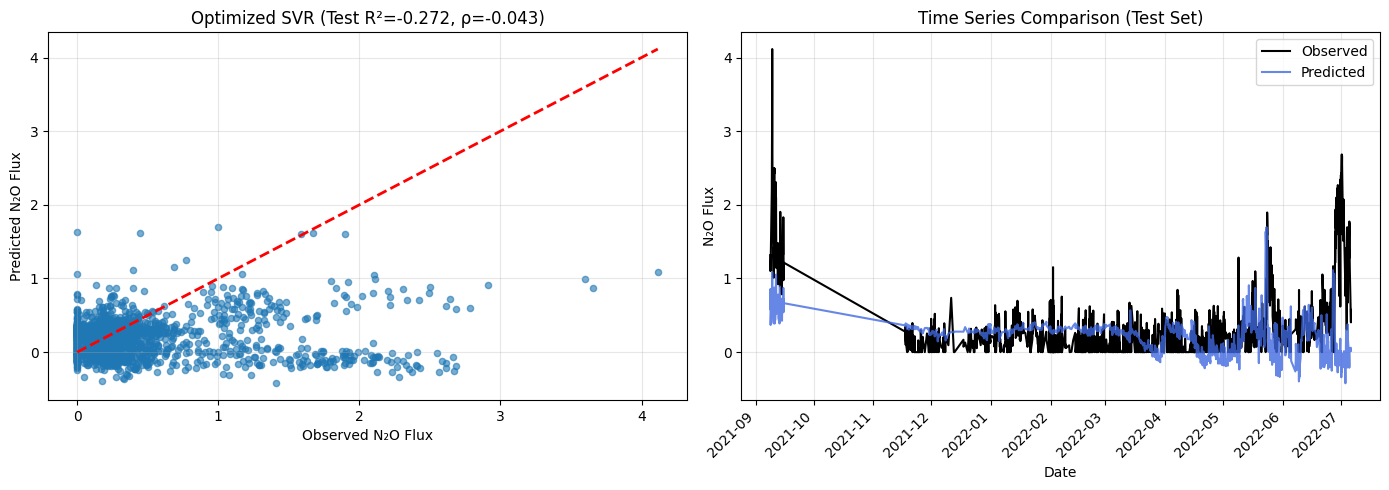


✓ Completed Hourly | Base
  Test R²: -0.2715
  Test ρ: -0.0428

OPTIMIZING: Hourly | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2014-01-01 08:15:00 → 2021-09-05 12:15:00 (17155 samples, 90.0%)
Test:      2021-09-05 12:45:00 → 2022-07-06 09:15:00 (1907 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: 0.1692
Completed 10/500 iterations. Best CV R²: 0.1740
Completed 15/500 iterations. Best CV R²: 0.1740
Completed 20/500 iterations. Best CV R²: 0.1740
Completed 25/500 iterations. Best CV R²: 0.1740
Completed 30/500 iterations. Best CV R²: 0.1740
Completed 35/500 iterations. Best CV R²: 0.1743
Completed 40/500 iterations. Best CV R²: 0.1743
Completed 45/500 iterations. Best CV R²: 0.1913
Completed 50/500 iterations. Best CV R²: 0.1913
Completed 55/500 iterations. Best CV R²: 0.1924
Completed 60/500 iterations. Best CV R²: 0.1944
Com

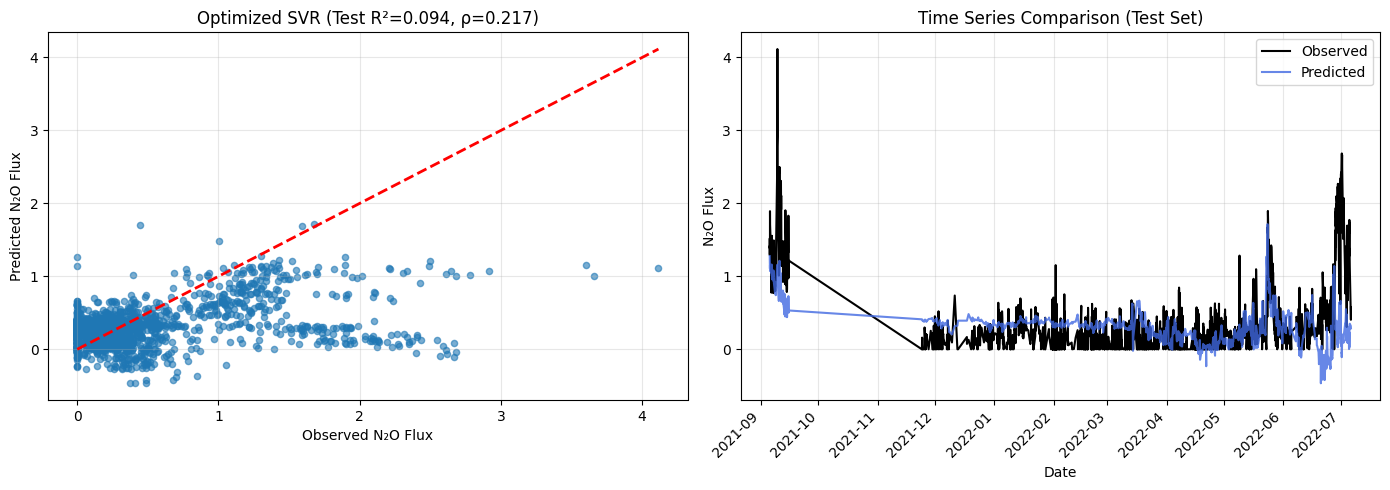


✓ Completed Hourly | Lag
  Test R²: 0.0938
  Test ρ: 0.2167

OPTIMIZING: Hourly | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2014-01-01 08:15:00 → 2021-09-05 12:15:00 (17155 samples, 90.0%)
Test:      2021-09-05 12:45:00 → 2022-07-06 09:15:00 (1907 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: 0.1441
Completed 10/500 iterations. Best CV R²: 0.1844
Completed 15/500 iterations. Best CV R²: 0.1844
Completed 20/500 iterations. Best CV R²: 0.1844
Completed 25/500 iterations. Best CV R²: 0.1844
Completed 30/500 iterations. Best CV R²: 0.1844
Completed 35/500 iterations. Best CV R²: 0.1844
Completed 40/500 iterations. Best CV R²: 0.1844
Completed 45/500 iterations. Best CV R²: 0.2252
Completed 50/500 iterations. Best CV R²: 0.2284
Completed 55/500 iterations. Best CV R²: 0.2284
Completed 60/500 iterations. Best CV R²: 0.2324


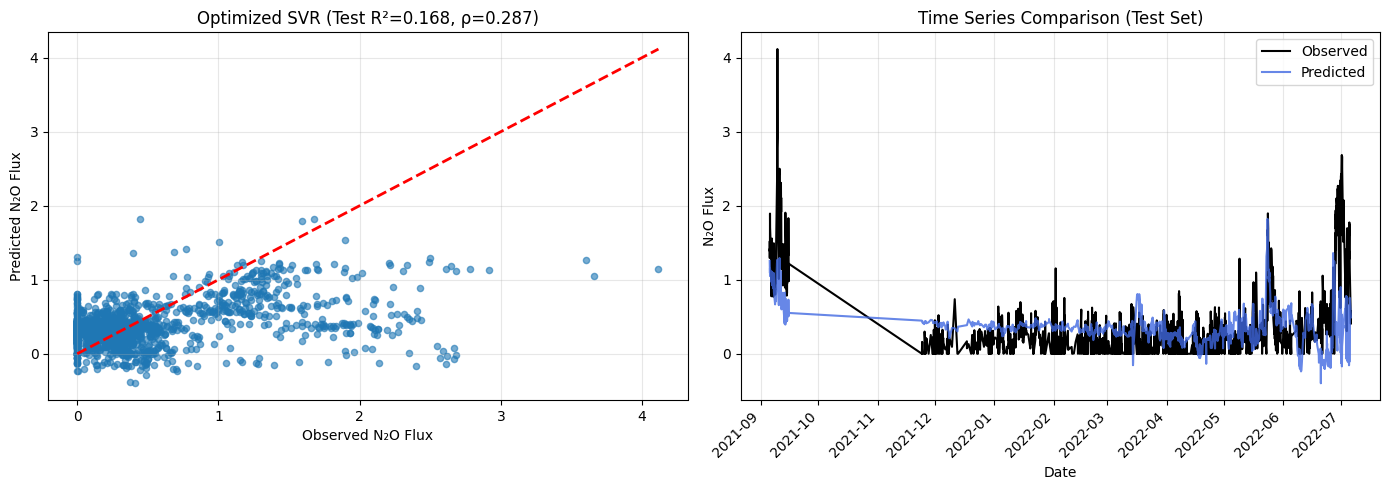


✓ Completed Hourly | Augmented
  Test R²: 0.1678
  Test ρ: 0.2872

OPTIMIZING: Daily | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2014-01-01 00:00:00 → 2021-11-24 00:00:00 (3690 samples, 90.0%)
Test:      2021-11-25 00:00:00 → 2022-07-06 00:00:00 (411 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: 0.0833
Completed 10/500 iterations. Best CV R²: 0.0833
Completed 15/500 iterations. Best CV R²: 0.0833
Completed 20/500 iterations. Best CV R²: 0.0833
Completed 25/500 iterations. Best CV R²: 0.0985
Completed 30/500 iterations. Best CV R²: 0.0985
Completed 35/500 iterations. Best CV R²: 0.0985
Completed 40/500 iterations. Best CV R²: 0.0985
Completed 45/500 iterations. Best CV R²: 0.0985
Completed 50/500 iterations. Best CV R²: 0.0985
Completed 55/500 iterations. Best CV R²: 0.0985
Completed 60/500 iterations. Best CV R²: 0.0985
Co

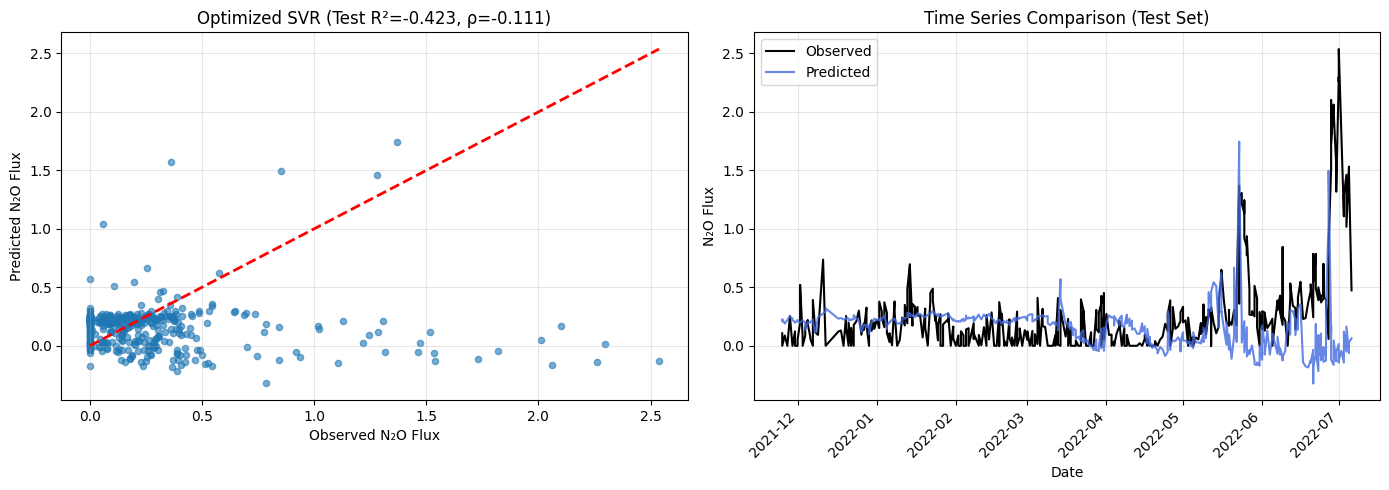


✓ Completed Daily | Base
  Test R²: -0.4226
  Test ρ: -0.1108

OPTIMIZING: Daily | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2014-01-01 00:00:00 → 2021-11-29 00:00:00 (3643 samples, 90.0%)
Test:      2021-11-29 00:00:00 → 2022-07-06 00:00:00 (405 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: 0.1202
Completed 10/500 iterations. Best CV R²: 0.1412
Completed 15/500 iterations. Best CV R²: 0.1412
Completed 20/500 iterations. Best CV R²: 0.1412
Completed 25/500 iterations. Best CV R²: 0.1714
Completed 30/500 iterations. Best CV R²: 0.1714
Completed 35/500 iterations. Best CV R²: 0.1714
Completed 40/500 iterations. Best CV R²: 0.1714
Completed 45/500 iterations. Best CV R²: 0.1714
Completed 50/500 iterations. Best CV R²: 0.1714
Completed 55/500 iterations. Best CV R²: 0.1714
Completed 60/500 iterations. Best CV R²: 0.1714
Complet

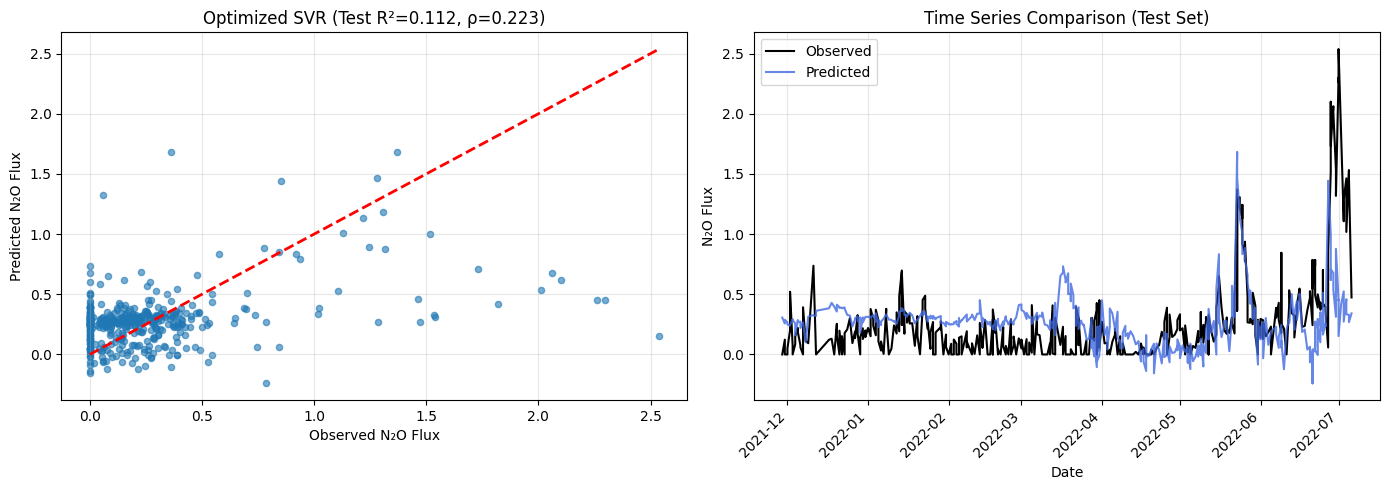


✓ Completed Daily | Lag
  Test R²: 0.1116
  Test ρ: 0.2227

OPTIMIZING: Daily | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2014-01-01 00:00:00 → 2021-11-29 00:00:00 (3643 samples, 90.0%)
Test:      2021-11-29 00:00:00 → 2022-07-06 00:00:00 (405 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: 0.0075
Completed 10/500 iterations. Best CV R²: 0.0294
Completed 15/500 iterations. Best CV R²: 0.0294
Completed 20/500 iterations. Best CV R²: 0.0294
Completed 25/500 iterations. Best CV R²: 0.0318
Completed 30/500 iterations. Best CV R²: 0.0321
Completed 35/500 iterations. Best CV R²: 0.0401
Completed 40/500 iterations. Best CV R²: 0.0419
Completed 45/500 iterations. Best CV R²: 0.0419
Completed 50/500 iterations. Best CV R²: 0.0784
Completed 55/500 iterations. Best CV R²: 0.0784
Completed 60/500 iterations. Best CV R²: 0.0784
Comp

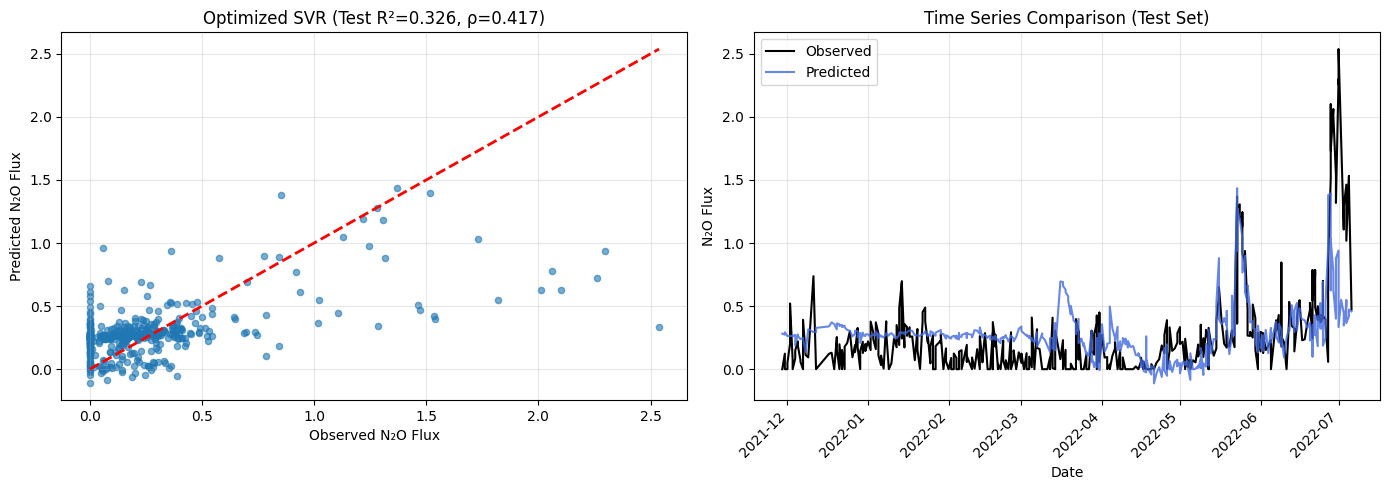


✓ Completed Daily | Augmented
  Test R²: 0.3260
  Test ρ: 0.4171


In [17]:
configurations = [
    ("Hourly", "Base", chamau_lag, base_predictors),
    ("Hourly", "Lag", chamau_lag, lag_predictors),
    ("Hourly", "Augmented", chamau_lag, augmented_predictors),
    ("Daily", "Base", chamau_daily, base_predictors),
    ("Daily", "Lag", chamau_daily, lag_predictors),
    ("Daily", "Augmented", chamau_daily, augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        best_params=best_params,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

In [11]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_svr_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2014-01-01 08:15:00 → 2021-07-31 12:15:00
Test  period: 2021-07-31 13:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.120
  Spearman ρ:        0.337

Running original Hourly | Lag...
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.334
  Spearman ρ:        0.481

Running original Hourly | Augmented...
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.324
  S

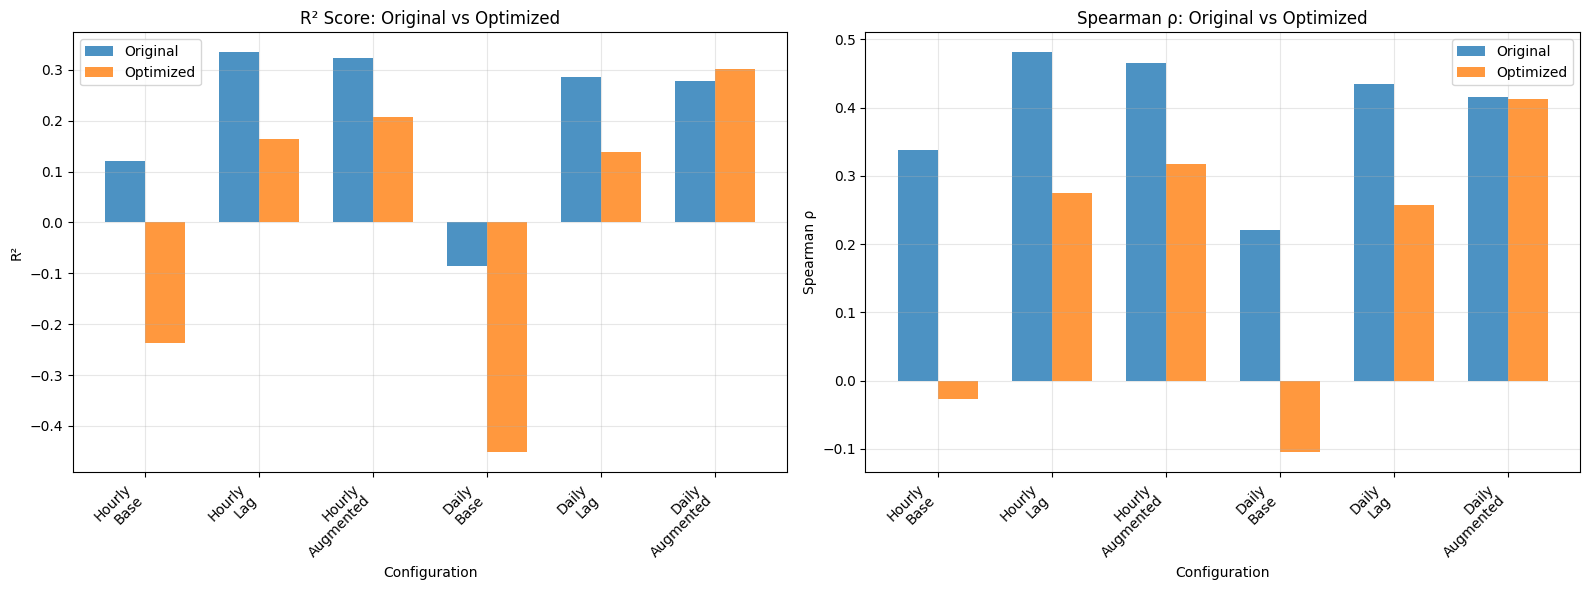

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Define dataset name
dataset_name = "Chamau"

# Create dataset subfolder inside existing svm_params folder
save_dir = os.path.join('svm_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to svm_params/Chamau!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 23
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/svm_params/Chamau

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ ORIGINAL   | ΔR²: -0.3576
Hourly          | Lag                  | ✓ ORIGINAL   | ΔR²: -0.1698
Hourly          | Augmented            | ✓ ORIGINAL   | ΔR²: -0.1167
Daily           | Base                 | ✓ ORIGINAL   | ΔR²: -0.3657
Daily           | Lag                  | ✓ ORIGINAL   | ΔR²: -0.1487
Daily           | Augmented            | ✓ OPTIMIZED  | ΔR²: +0.0232


# Experiment 2: Oensingen 2021-23

In [18]:
# FIX TIMESTAMP
oensingen_2_lag['Timestamp'] = pd.to_datetime(oensingen_2_lag['Timestamp'])
oensingen_2_lag = oensingen_2_lag.set_index('Timestamp').sort_index()

oensingen_2_daily['Date'] = pd.to_datetime(oensingen_2_daily['Date'])
oensingen_2_daily = oensingen_2_daily.set_index('Date').sort_index()

In [19]:
# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation", "Fertilizer_N_kg_ha"
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]


OPTIMIZING: Hourly | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2022-08-30 11:45:00 → 2023-08-24 11:45:00 (5930 samples, 90.0%)
Test:      2023-08-24 14:45:00 → 2023-10-05 12:15:00 (659 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.2255
Completed 10/500 iterations. Best CV R²: -0.2255
Completed 15/500 iterations. Best CV R²: -0.2255
Completed 20/500 iterations. Best CV R²: -0.2255
Completed 25/500 iterations. Best CV R²: -0.2255
Completed 30/500 iterations. Best CV R²: -0.1406
Completed 35/500 iterations. Best CV R²: -0.1406
Completed 40/500 iterations. Best CV R²: -0.1406
Completed 45/500 iterations. Best CV R²: -0.1406
Completed 50/500 iterations. Best CV R²: -0.1406
Completed 55/500 iterations. Best CV R²: -0.1406
Completed 60/500 iterations. Best CV R²: -0.1406
Completed 65/500 iterations. Best CV R²: -0.1406
Complet

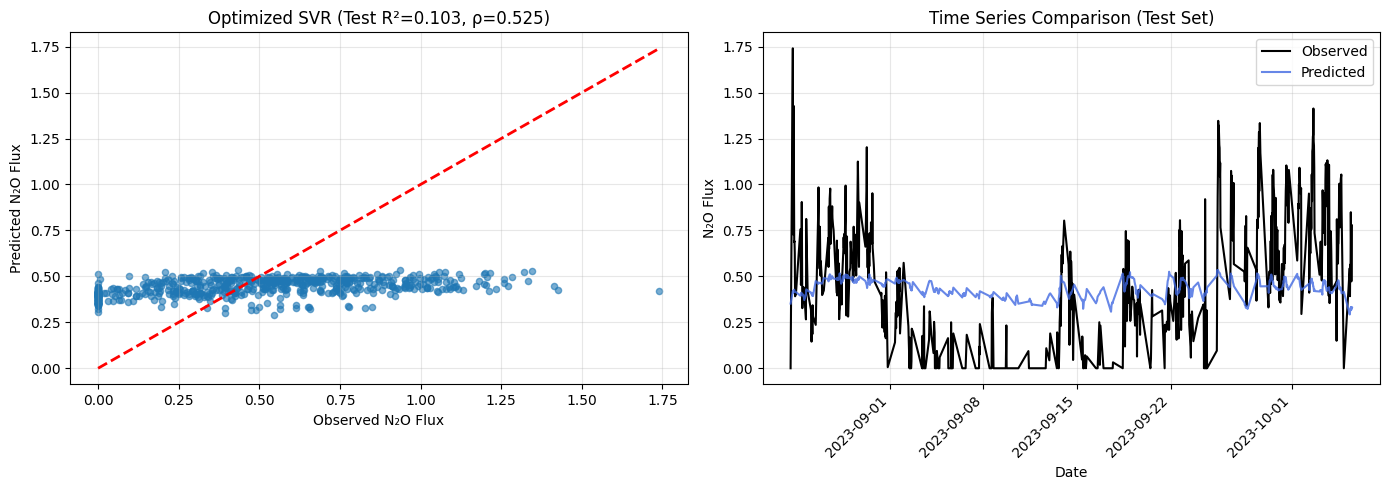


✓ Completed Hourly | Base
  Test R²: 0.1031
  Test ρ: 0.5248

OPTIMIZING: Hourly | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2022-08-30 11:45:00 → 2023-08-24 11:45:00 (5930 samples, 90.0%)
Test:      2023-08-24 14:45:00 → 2023-10-05 12:15:00 (659 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.0060
Completed 10/500 iterations. Best CV R²: -0.0022
Completed 15/500 iterations. Best CV R²: -0.0022
Completed 20/500 iterations. Best CV R²: 0.0051
Completed 25/500 iterations. Best CV R²: 0.0070
Completed 30/500 iterations. Best CV R²: 0.0070
Completed 35/500 iterations. Best CV R²: 0.0070
Completed 40/500 iterations. Best CV R²: 0.0070
Completed 45/500 iterations. Best CV R²: 0.0740
Completed 50/500 iterations. Best CV R²: 0.2907
Completed 55/500 iterations. Best CV R²: 0.3000
Completed 60/500 iterations. Best CV R²: 0.3000
Comp

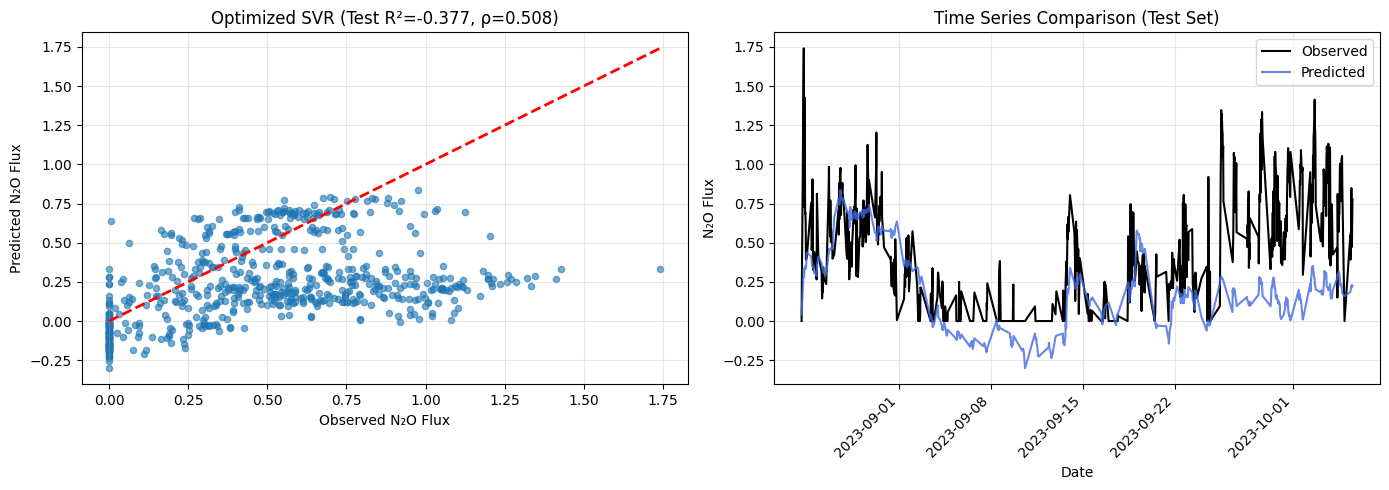


✓ Completed Hourly | Lag
  Test R²: -0.3766
  Test ρ: 0.5076

OPTIMIZING: Hourly | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2022-08-30 11:45:00 → 2023-08-24 11:45:00 (5930 samples, 90.0%)
Test:      2023-08-24 14:45:00 → 2023-10-05 12:15:00 (659 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.0241
Completed 10/500 iterations. Best CV R²: 0.0024
Completed 15/500 iterations. Best CV R²: 0.0024
Completed 20/500 iterations. Best CV R²: 0.0024
Completed 25/500 iterations. Best CV R²: 0.0024
Completed 30/500 iterations. Best CV R²: 0.0024
Completed 35/500 iterations. Best CV R²: 0.0024
Completed 40/500 iterations. Best CV R²: 0.0024
Completed 45/500 iterations. Best CV R²: 0.0091
Completed 50/500 iterations. Best CV R²: 0.0091
Completed 55/500 iterations. Best CV R²: 0.0091
Completed 60/500 iterations. Best CV R²: 0.0091


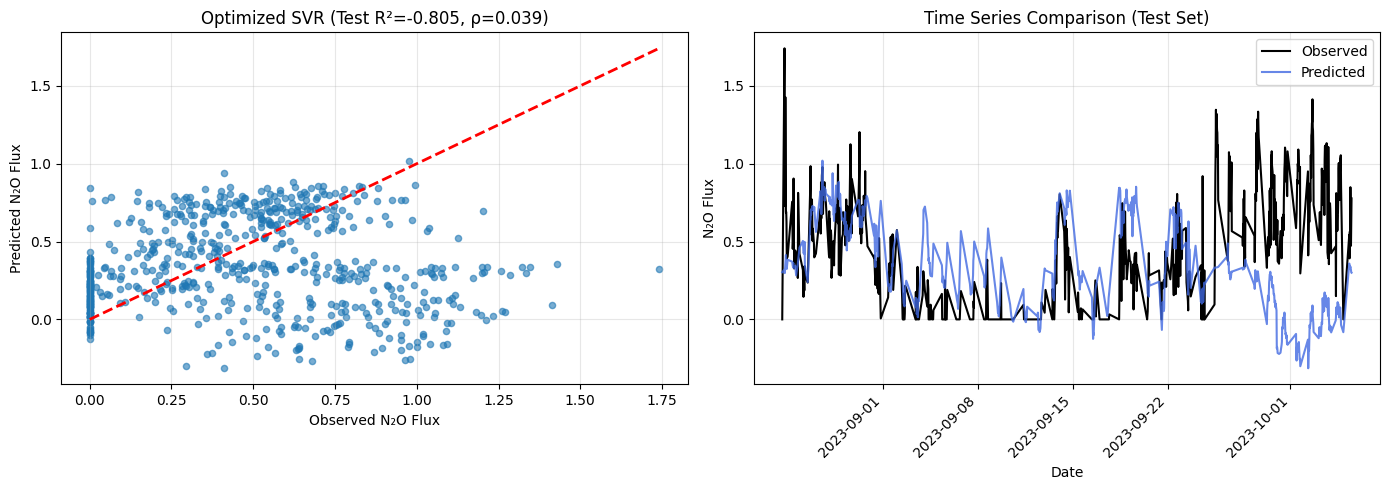


✓ Completed Hourly | Augmented
  Test R²: -0.8049
  Test ρ: 0.0391

OPTIMIZING: Daily | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2022-08-30 00:00:00 → 2023-08-28 00:00:00 (336 samples, 89.8%)
Test:      2023-08-29 00:00:00 → 2023-10-05 00:00:00 (38 samples, 10.2%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: 0.0302
Completed 10/500 iterations. Best CV R²: 0.0909
Completed 15/500 iterations. Best CV R²: 0.0909
Completed 20/500 iterations. Best CV R²: 0.0986
Completed 25/500 iterations. Best CV R²: 0.1316
Completed 30/500 iterations. Best CV R²: 0.1316
Completed 35/500 iterations. Best CV R²: 0.1316
Completed 40/500 iterations. Best CV R²: 0.1316
Completed 45/500 iterations. Best CV R²: 0.1316
Completed 50/500 iterations. Best CV R²: 0.1316
Completed 55/500 iterations. Best CV R²: 0.1316
Completed 60/500 iterations. Best CV R²: 0.1316
Com

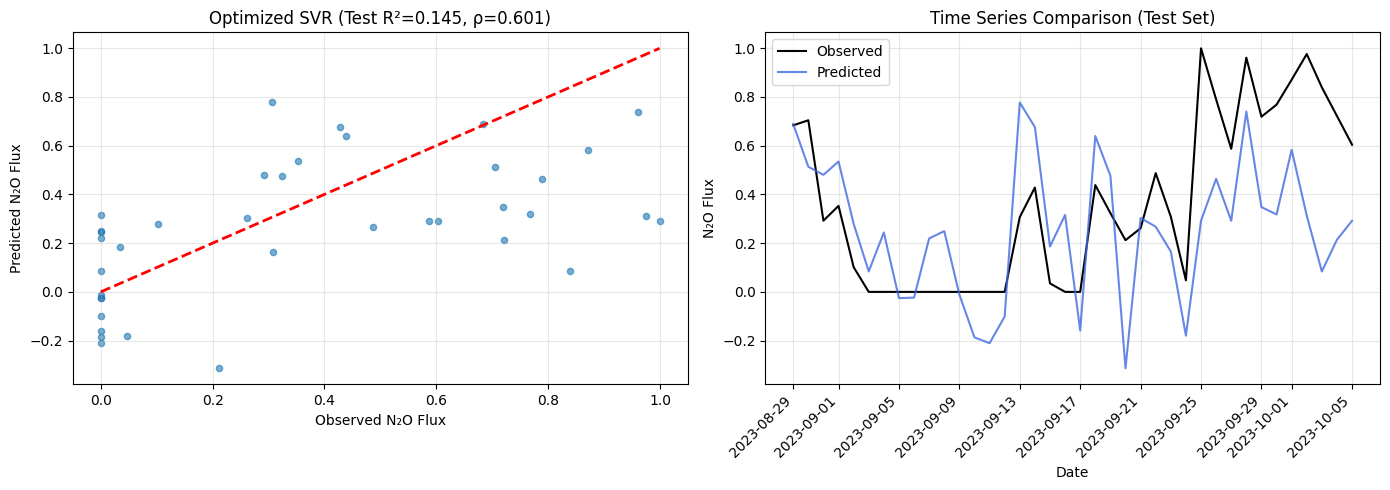


✓ Completed Daily | Base
  Test R²: 0.1455
  Test ρ: 0.6011

OPTIMIZING: Daily | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2022-09-06 00:00:00 → 2023-08-29 00:00:00 (330 samples, 89.9%)
Test:      2023-08-30 00:00:00 → 2023-10-05 00:00:00 (37 samples, 10.1%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: 0.1277
Completed 10/500 iterations. Best CV R²: 0.1277
Completed 15/500 iterations. Best CV R²: 0.1419
Completed 20/500 iterations. Best CV R²: 0.1419
Completed 25/500 iterations. Best CV R²: 0.1646
Completed 30/500 iterations. Best CV R²: 0.1646
Completed 35/500 iterations. Best CV R²: 0.1673
Completed 40/500 iterations. Best CV R²: 0.1673
Completed 45/500 iterations. Best CV R²: 0.1673
Completed 50/500 iterations. Best CV R²: 0.1673
Completed 55/500 iterations. Best CV R²: 0.1673
Completed 60/500 iterations. Best CV R²: 0.1673
Completed 6

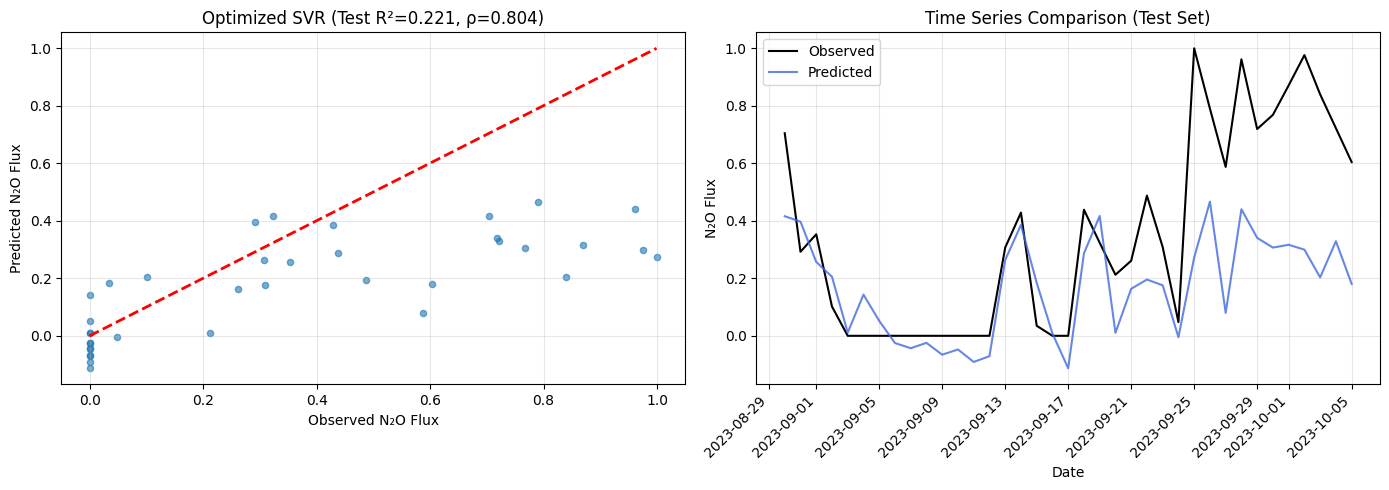


✓ Completed Daily | Lag
  Test R²: 0.2209
  Test ρ: 0.8039

OPTIMIZING: Daily | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2022-09-06 00:00:00 → 2023-08-29 00:00:00 (330 samples, 89.9%)
Test:      2023-08-30 00:00:00 → 2023-10-05 00:00:00 (37 samples, 10.1%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: 0.0947
Completed 10/500 iterations. Best CV R²: 0.0947
Completed 15/500 iterations. Best CV R²: 0.0947
Completed 20/500 iterations. Best CV R²: 0.0947
Completed 25/500 iterations. Best CV R²: 0.1019
Completed 30/500 iterations. Best CV R²: 0.1019
Completed 35/500 iterations. Best CV R²: 0.1051
Completed 40/500 iterations. Best CV R²: 0.1051
Completed 45/500 iterations. Best CV R²: 0.1259
Completed 50/500 iterations. Best CV R²: 0.1269
Completed 55/500 iterations. Best CV R²: 0.1328
Completed 60/500 iterations. Best CV R²: 0.1328
Comple

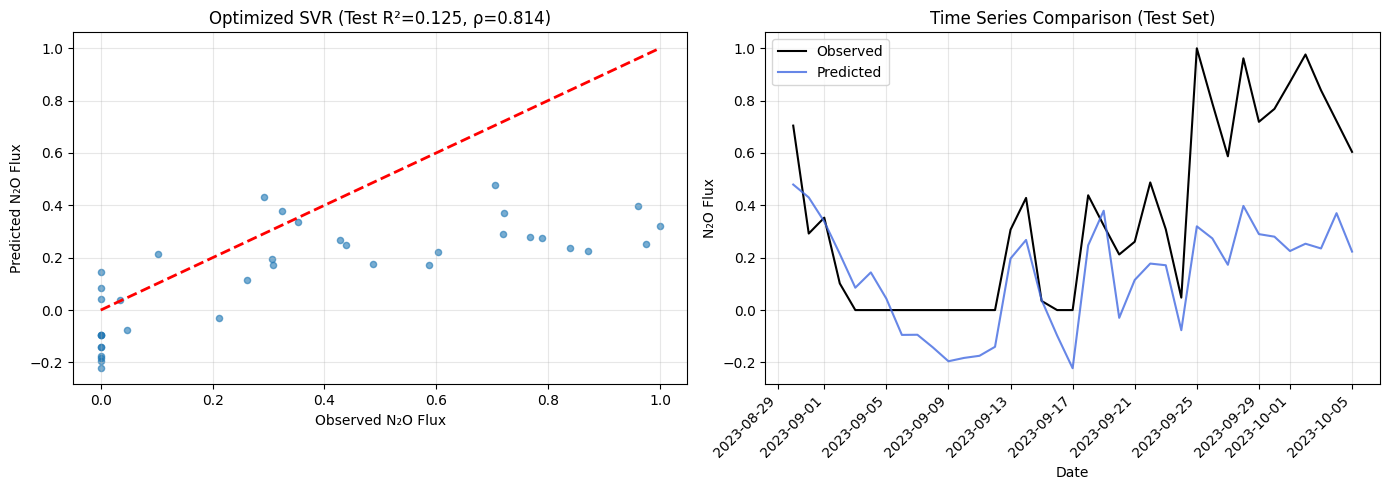


✓ Completed Daily | Augmented
  Test R²: 0.1246
  Test ρ: 0.8138


In [21]:
configurations = [
    ("Hourly", "Base", oensingen_2_lag, base_predictors),
    ("Hourly", "Lag", oensingen_2_lag, hourly_lag_predictors),
    ("Hourly", "Augmented", oensingen_2_lag, hourly_augmented_predictors),
    ("Daily", "Base", oensingen_2_daily, base_predictors),
    ("Daily", "Lag", oensingen_2_daily, daily_lag_predictors),
    ("Daily", "Augmented", oensingen_2_daily, daily_augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        best_params=best_params,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

In [22]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_svr_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.401
  Spearman ρ:        0.360

Running original Hourly | Lag...
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.318
  Spearman ρ:        0.470

Running original Hourly | Augmented...
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.410


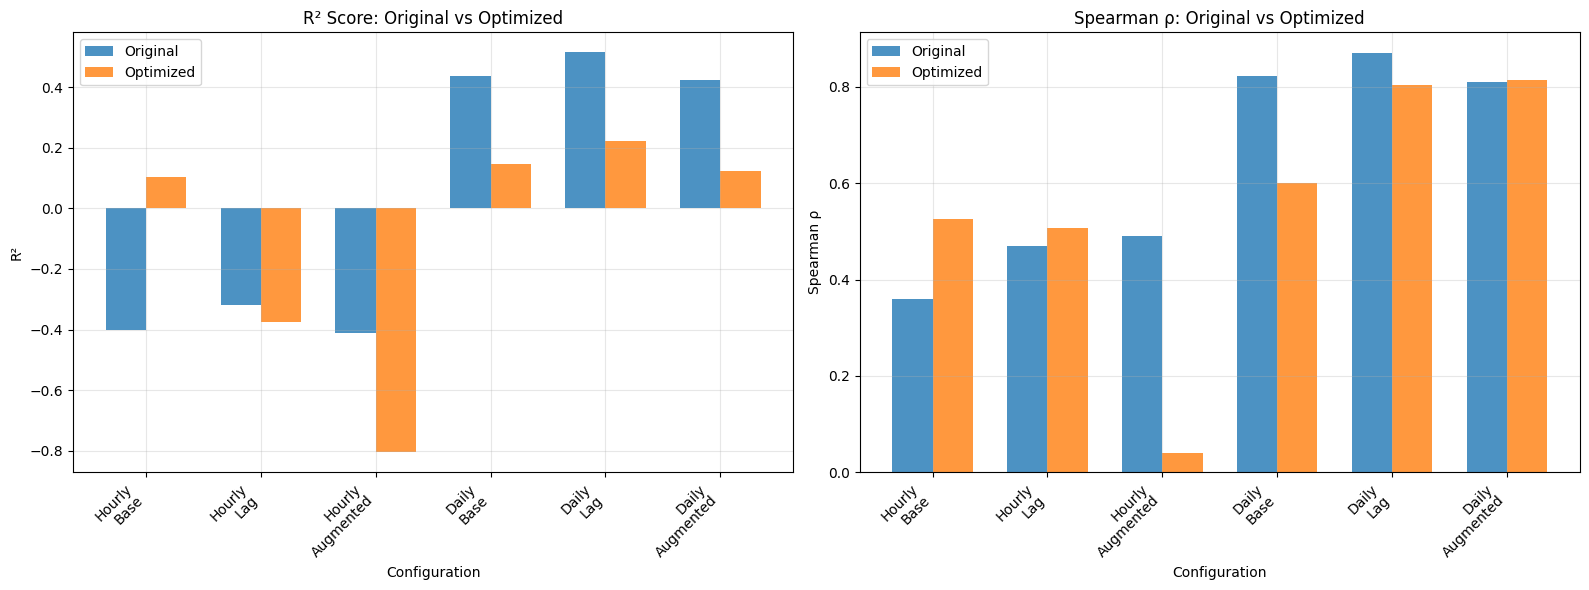

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Define dataset name
dataset_name = "Oensingen_2021-23"

# Create dataset subfolder inside existing svm_params folder
save_dir = os.path.join('svm_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to svm_params/Oensingen_2021-23!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 23
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/svm_params/Oensingen_2021-23

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ OPTIMIZED  | ΔR²: +0.5036
Hourly          | Lag                  | ✓ ORIGINAL   | ΔR²: -0.0585
Hourly          | Augmented            | ✓ ORIGINAL   | ΔR²: -0.3948
Daily           | Base                 | ✓ ORIGINAL   | ΔR²: -0.2919
Daily           | Lag                  | ✓ ORIGINAL   | ΔR²: -0.2937
Daily           | Augmented            | ✓ ORIGINAL   | ΔR²: -0.2982


# Experiment 3: Forel

In [25]:
# FIX TIMESTAMP
forel_lag['Timestamp'] = pd.to_datetime(forel_lag['Timestamp'])
forel_lag = forel_lag.set_index('Timestamp').sort_index()

forel_daily['Date'] = pd.to_datetime(forel_daily['Date'])
forel_daily = forel_daily.set_index('Date').sort_index()

In [26]:
# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Fertilizer_N_kg_ha"
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", 

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]


OPTIMIZING: Hourly | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2024-03-14 11:15:00 → 2025-03-14 06:45:00 (5827 samples, 90.0%)
Test:      2025-03-14 07:15:00 → 2025-04-28 16:15:00 (648 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.6893
Completed 10/500 iterations. Best CV R²: -0.6893
Completed 15/500 iterations. Best CV R²: -0.6893
Completed 20/500 iterations. Best CV R²: -0.6893
Completed 25/500 iterations. Best CV R²: -0.3942
Completed 30/500 iterations. Best CV R²: -0.3100
Completed 35/500 iterations. Best CV R²: -0.3100
Completed 40/500 iterations. Best CV R²: -0.3100
Completed 45/500 iterations. Best CV R²: -0.3100
Completed 50/500 iterations. Best CV R²: -0.3100
Completed 55/500 iterations. Best CV R²: -0.3100
Completed 60/500 iterations. Best CV R²: -0.3100
Completed 65/500 iterations. Best CV R²: -0.3100
Complet

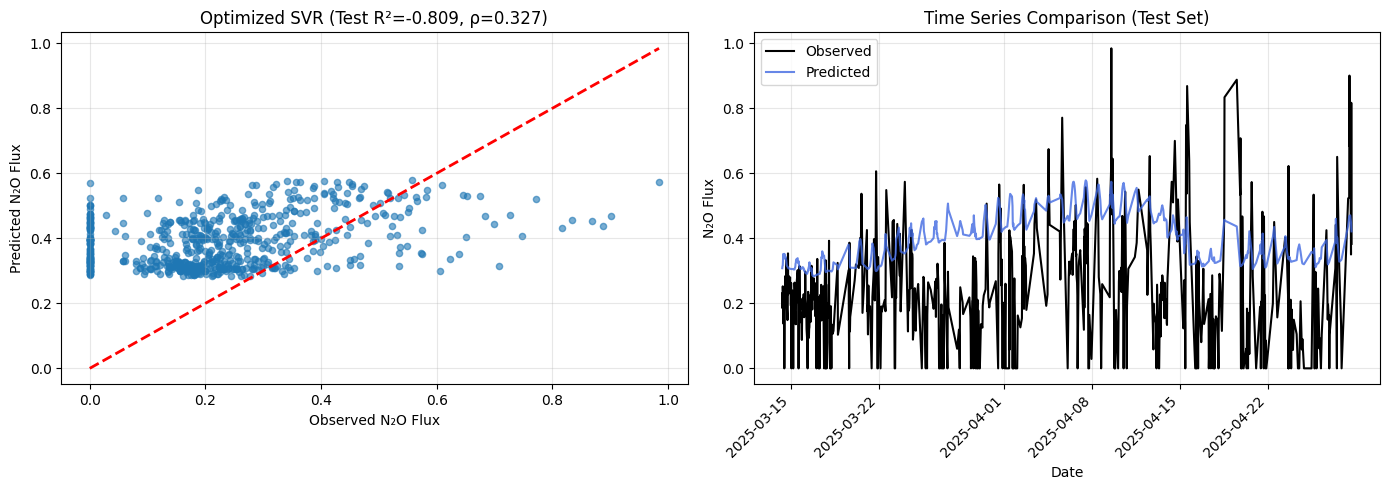


✓ Completed Hourly | Base
  Test R²: -0.8093
  Test ρ: 0.3267

OPTIMIZING: Hourly | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2024-03-21 04:45:00 → 2025-03-14 13:45:00 (5723 samples, 90.0%)
Test:      2025-03-14 14:45:00 → 2025-04-28 16:15:00 (636 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -2.8082
Completed 10/500 iterations. Best CV R²: -1.1110
Completed 15/500 iterations. Best CV R²: -1.1110
Completed 20/500 iterations. Best CV R²: -1.1110
Completed 25/500 iterations. Best CV R²: -0.8570
Completed 30/500 iterations. Best CV R²: -0.8570
Completed 35/500 iterations. Best CV R²: -0.8570
Completed 40/500 iterations. Best CV R²: -0.8570
Completed 45/500 iterations. Best CV R²: -0.8570
Completed 50/500 iterations. Best CV R²: -0.8570
Completed 55/500 iterations. Best CV R²: -0.8570
Completed 60/500 iterations. Best CV R²: -0

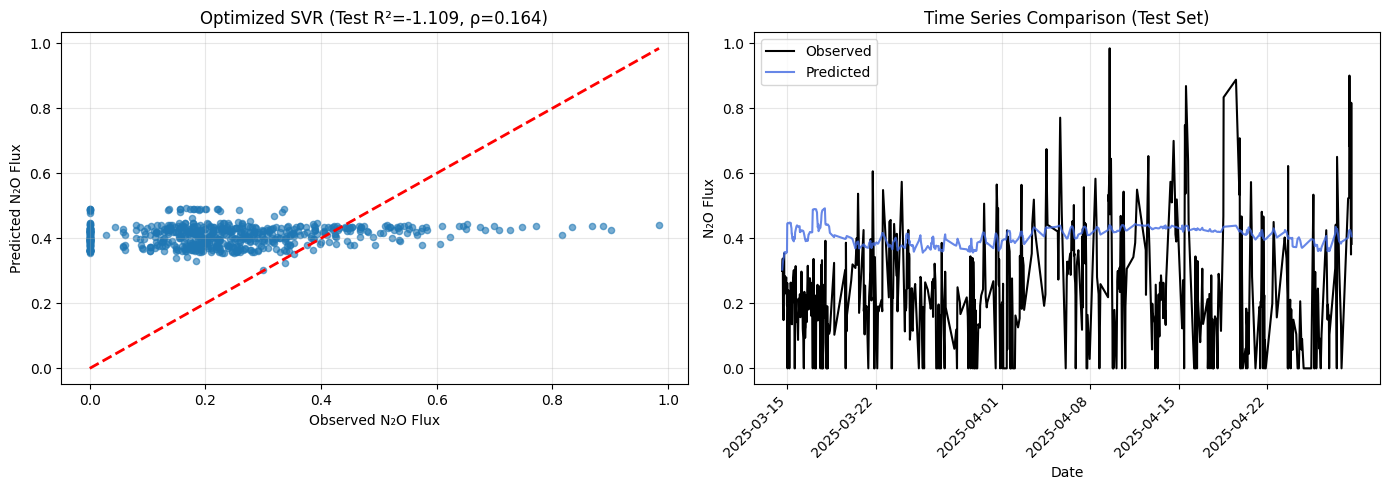


✓ Completed Hourly | Lag
  Test R²: -1.1089
  Test ρ: 0.1643

OPTIMIZING: Hourly | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2024-03-21 04:45:00 → 2025-03-14 13:45:00 (5723 samples, 90.0%)
Test:      2025-03-14 14:45:00 → 2025-04-28 16:15:00 (636 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -1.9070
Completed 10/500 iterations. Best CV R²: -0.7459
Completed 15/500 iterations. Best CV R²: -0.7459
Completed 20/500 iterations. Best CV R²: -0.7459
Completed 25/500 iterations. Best CV R²: -0.6413
Completed 30/500 iterations. Best CV R²: -0.6413
Completed 35/500 iterations. Best CV R²: -0.6217
Completed 40/500 iterations. Best CV R²: -0.6217
Completed 45/500 iterations. Best CV R²: -0.6217
Completed 50/500 iterations. Best CV R²: -0.6217
Completed 55/500 iterations. Best CV R²: -0.6097
Completed 60/500 iterations. Best CV R

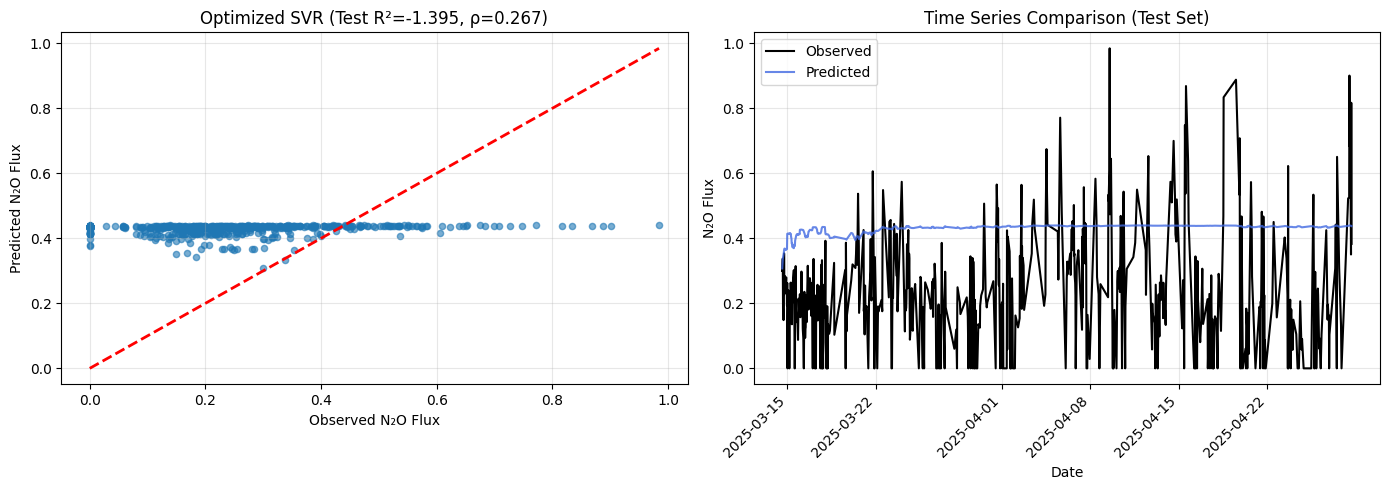


✓ Completed Hourly | Augmented
  Test R²: -1.3951
  Test ρ: 0.2673

OPTIMIZING: Daily | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2024-03-14 00:00:00 → 2025-03-18 00:00:00 (361 samples, 89.8%)
Test:      2025-03-19 00:00:00 → 2025-04-28 00:00:00 (41 samples, 10.2%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.9522
Completed 10/500 iterations. Best CV R²: -0.9522
Completed 15/500 iterations. Best CV R²: -0.9522
Completed 20/500 iterations. Best CV R²: -0.9462
Completed 25/500 iterations. Best CV R²: -0.8414
Completed 30/500 iterations. Best CV R²: -0.8414
Completed 35/500 iterations. Best CV R²: -0.8414
Completed 40/500 iterations. Best CV R²: -0.8414
Completed 45/500 iterations. Best CV R²: -0.7515
Completed 50/500 iterations. Best CV R²: -0.7515
Completed 55/500 iterations. Best CV R²: -0.7515
Completed 60/500 iterations. Best CV R²:

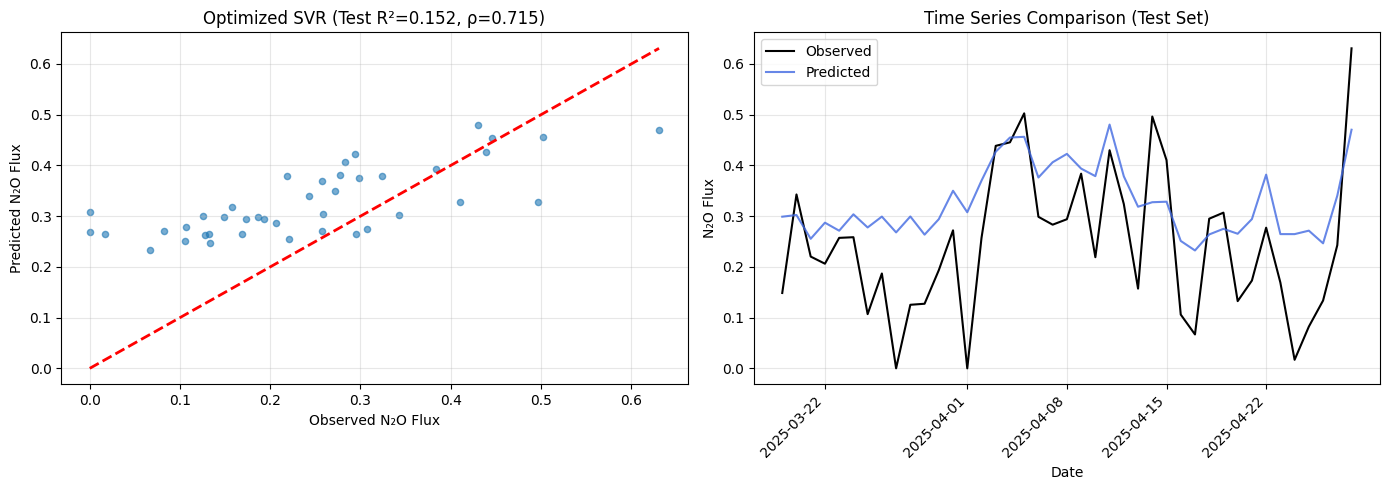


✓ Completed Daily | Base
  Test R²: 0.1522
  Test ρ: 0.7151

OPTIMIZING: Daily | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2024-03-21 00:00:00 → 2025-03-19 00:00:00 (355 samples, 89.9%)
Test:      2025-03-20 00:00:00 → 2025-04-28 00:00:00 (40 samples, 10.1%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.8609
Completed 10/500 iterations. Best CV R²: -0.8392
Completed 15/500 iterations. Best CV R²: -0.7914
Completed 20/500 iterations. Best CV R²: -0.7621


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 25/500 iterations. Best CV R²: -0.7610
Completed 30/500 iterations. Best CV R²: -0.7610
Completed 35/500 iterations. Best CV R²: -0.7610
Completed 40/500 iterations. Best CV R²: -0.7610
Completed 45/500 iterations. Best CV R²: -0.7610
Completed 50/500 iterations. Best CV R²: -0.7610
Completed 55/500 iterations. Best CV R²: -0.7610
Completed 60/500 iterations. Best CV R²: -0.7610
Completed 65/500 iterations. Best CV R²: -0.7610
Completed 70/500 iterations. Best CV R²: -0.7601
Completed 75/500 iterations. Best CV R²: -0.7601
Completed 80/500 iterations. Best CV R²: -0.7601
Completed 85/500 iterations. Best CV R²: -0.7601
Completed 90/500 iterations. Best CV R²: -0.7601
Completed 95/500 iterations. Best CV R²: -0.7601
Completed 100/500 iterations. Best CV R²: -0.7601
Completed 105/500 iterations. Best CV R²: -0.7601
Completed 110/500 iterations. Best CV R²: -0.7601
Completed 115/500 iterations. Best CV R²: -0.7601
Completed 120/500 iterations. Best CV R²: -0.7601
Completed 125/5

/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 340/500 iterations. Best CV R²: -0.7594
Completed 345/500 iterations. Best CV R²: -0.7594
Completed 350/500 iterations. Best CV R²: -0.7594
Completed 355/500 iterations. Best CV R²: -0.7594
Completed 360/500 iterations. Best CV R²: -0.7594
Completed 365/500 iterations. Best CV R²: -0.7594
Completed 370/500 iterations. Best CV R²: -0.7594
Completed 375/500 iterations. Best CV R²: -0.7594
Completed 380/500 iterations. Best CV R²: -0.7594
Completed 385/500 iterations. Best CV R²: -0.7594
Completed 390/500 iterations. Best CV R²: -0.7594
Completed 395/500 iterations. Best CV R²: -0.7594
Completed 400/500 iterations. Best CV R²: -0.7594
Completed 405/500 iterations. Best CV R²: -0.7592
Completed 410/500 iterations. Best CV R²: -0.7585
Completed 415/500 iterations. Best CV R²: -0.7585
Completed 420/500 iterations. Best CV R²: -0.7585
Completed 425/500 iterations. Best CV R²: -0.7585
Completed 430/500 iterations. Best CV R²: -0.7585
Completed 435/500 iterations. Best CV R²: -0.7585


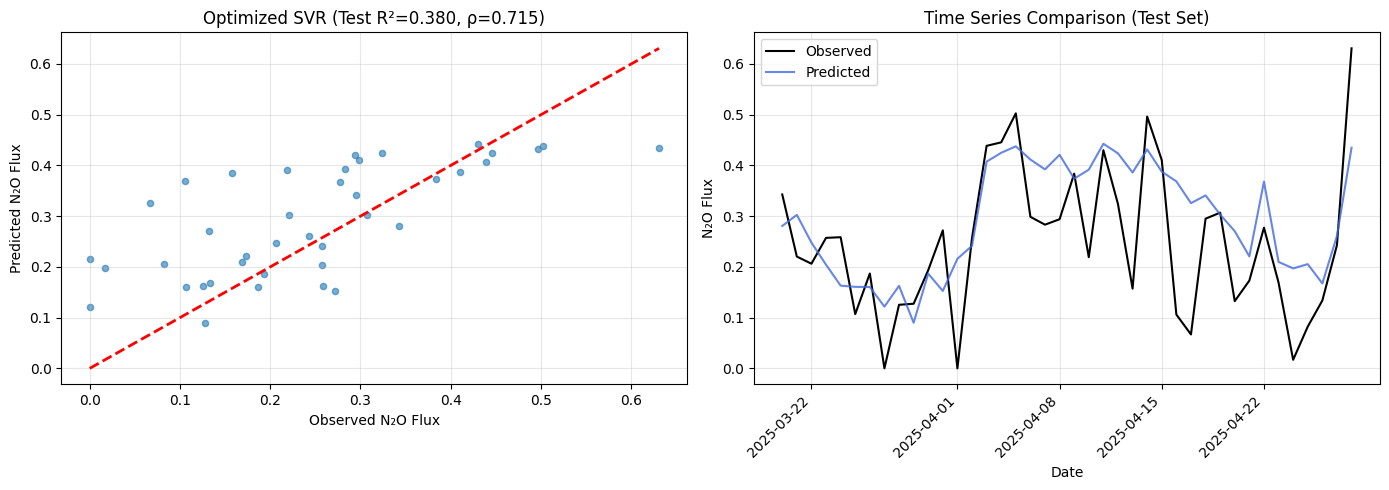


✓ Completed Daily | Lag
  Test R²: 0.3799
  Test ρ: 0.7150

OPTIMIZING: Daily | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2024-03-21 00:00:00 → 2025-03-19 00:00:00 (355 samples, 89.9%)
Test:      2025-03-20 00:00:00 → 2025-04-28 00:00:00 (40 samples, 10.1%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.6313
Completed 10/500 iterations. Best CV R²: -0.6033
Completed 15/500 iterations. Best CV R²: -0.6033
Completed 20/500 iterations. Best CV R²: -0.6033
Completed 25/500 iterations. Best CV R²: -0.5829


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 30/500 iterations. Best CV R²: -0.5829
Completed 35/500 iterations. Best CV R²: -0.5829
Completed 40/500 iterations. Best CV R²: -0.5829
Completed 45/500 iterations. Best CV R²: -0.5829
Completed 50/500 iterations. Best CV R²: -0.5829
Completed 55/500 iterations. Best CV R²: -0.5829
Completed 60/500 iterations. Best CV R²: -0.5829


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 65/500 iterations. Best CV R²: -0.5829
Completed 70/500 iterations. Best CV R²: -0.5829
Completed 75/500 iterations. Best CV R²: -0.5824
Completed 80/500 iterations. Best CV R²: -0.5824
Completed 85/500 iterations. Best CV R²: -0.5824
Completed 90/500 iterations. Best CV R²: -0.5823


...

Completed 455/500 iterations. Best CV R²: -0.5823
Completed 460/500 iterations. Best CV R²: -0.5823
Completed 465/500 iterations. Best CV R²: -0.5823
Completed 470/500 iterations. Best CV R²: -0.5823
Completed 475/500 iterations. Best CV R²: -0.5823


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 480/500 iterations. Best CV R²: -0.5823
Completed 485/500 iterations. Best CV R²: -0.5823
Completed 490/500 iterations. Best CV R²: -0.5823
Completed 495/500 iterations. Best CV R²: -0.5823


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 500/500 iterations. Best CV R²: -0.5823

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  kernel: rbf
  C: 2.1256421260195064
  epsilon: 0.2830111673627198
  cache_size: 1000
  gamma: scale

Best CV R² (mean across 3 folds): -0.5823

Training final SVR model on 355 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS BASELINE MODEL)
R² (linear scale): -0.1806
Spearman ρ:        0.4100


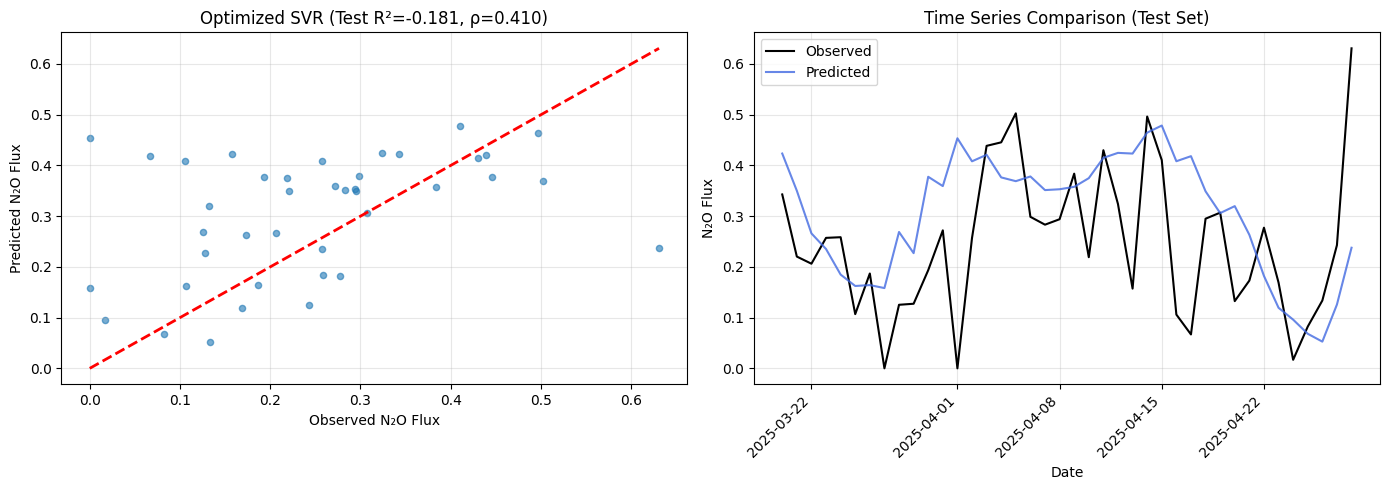


✓ Completed Daily | Augmented
  Test R²: -0.1806
  Test ρ: 0.4100


In [27]:
configurations = [
    ("Hourly", "Base", forel_lag, base_predictors),
    ("Hourly", "Lag", forel_lag, lag_predictors),
    ("Hourly", "Augmented", forel_lag, augmented_predictors),
    ("Daily", "Base", forel_daily, base_predictors),
    ("Daily", "Lag", forel_daily, lag_predictors),
    ("Daily", "Augmented", forel_daily, augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        best_params=best_params,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

In [28]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_svr_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2024-03-07 21:15:00 → 2025-03-01 19:15:00
Test  period: 2025-03-01 19:45:00 → 2025-05-03 13:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.111
  Spearman ρ:        0.428

Running original Hourly | Lag...
Train period: 2024-03-07 21:15:00 → 2025-02-17 21:15:00
Test  period: 2025-02-18 03:15:00 → 2025-05-03 13:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.001
  Spearman ρ:        0.337

Running original Hourly | Augmented...
Train period: 2024-03-07 21:15:00 → 2025-02-17 21:15:00
Test  period: 2025-02-18 03:15:00 → 2025-05-03 13:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.156
  

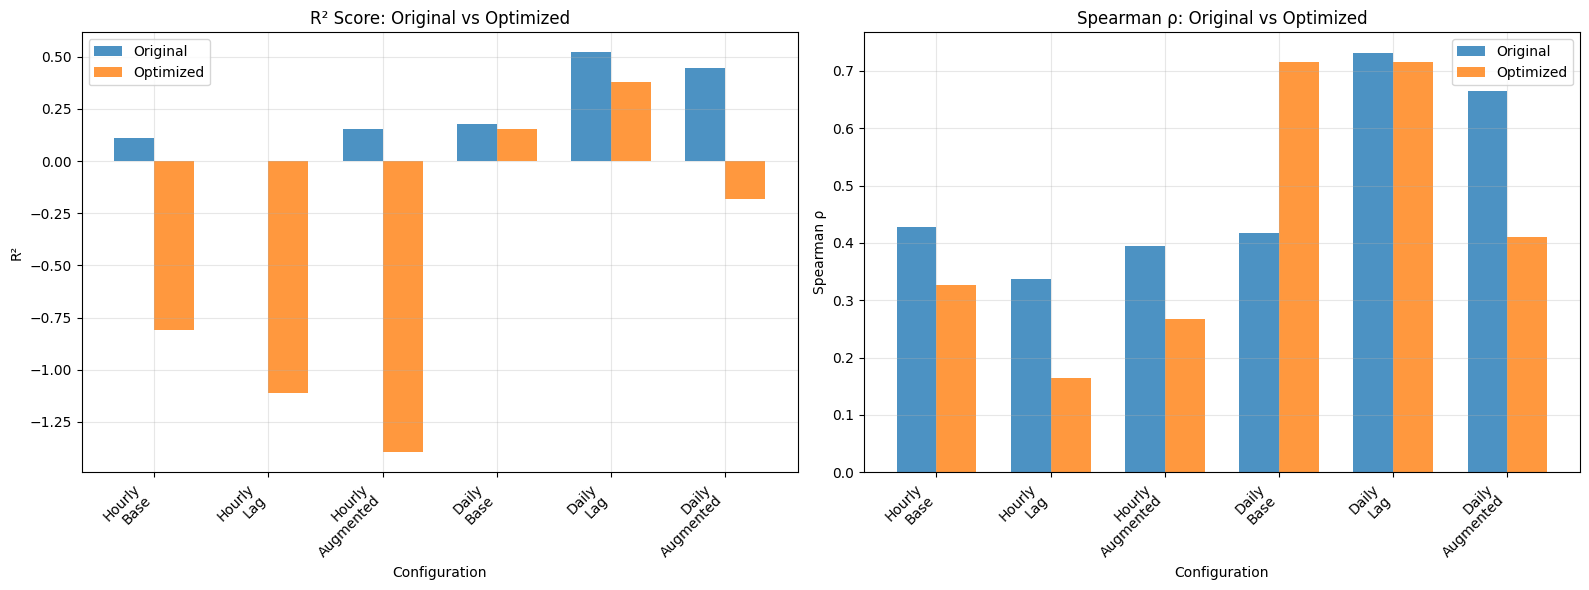

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Define dataset name
dataset_name = "Forel"

# Create dataset subfolder inside existing svm_params folder
save_dir = os.path.join('svm_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to svm_params/Forel!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 23
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/svm_params/Forel

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ ORIGINAL   | ΔR²: -0.9201
Hourly          | Lag                  | ✓ ORIGINAL   | ΔR²: -1.1083
Hourly          | Augmented            | ✓ ORIGINAL   | ΔR²: -1.5507
Daily           | Base                 | ✓ ORIGINAL   | ΔR²: -0.0252
Daily           | Lag                  | ✓ ORIGINAL   | ΔR²: -0.1414
Daily           | Augmented            | ✓ ORIGINAL   | ΔR²: -0.6271


# Experiment 4: Oensingen 2018-19

In [31]:
# FIX TIMESTAMP
oensingen_1_lag['Timestamp'] = pd.to_datetime(oensingen_1_lag['Timestamp'])
oensingen_1_lag = oensingen_1_lag.set_index('Timestamp').sort_index()

oensingen_1_daily['Date'] = pd.to_datetime(oensingen_1_daily['Date'])
oensingen_1_daily = oensingen_1_daily.set_index('Date').sort_index()

In [33]:
# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "SoilCultivation"
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]


OPTIMIZING: Hourly | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2018-07-12 07:45:00 → 2019-09-14 08:45:00 (2808 samples, 90.0%)
Test:      2019-09-14 09:15:00 → 2019-10-02 02:15:00 (312 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.4506
Completed 10/500 iterations. Best CV R²: -0.1562
Completed 15/500 iterations. Best CV R²: -0.1562
Completed 20/500 iterations. Best CV R²: -0.1562
Completed 25/500 iterations. Best CV R²: -0.1562
Completed 30/500 iterations. Best CV R²: -0.1072
Completed 35/500 iterations. Best CV R²: -0.1072
Completed 40/500 iterations. Best CV R²: -0.1049
Completed 45/500 iterations. Best CV R²: -0.1049
Completed 50/500 iterations. Best CV R²: -0.1049
Completed 55/500 iterations. Best CV R²: -0.1049
Completed 60/500 iterations. Best CV R²: -0.0244
Completed 65/500 iterations. Best CV R²: -0.0244
Complet

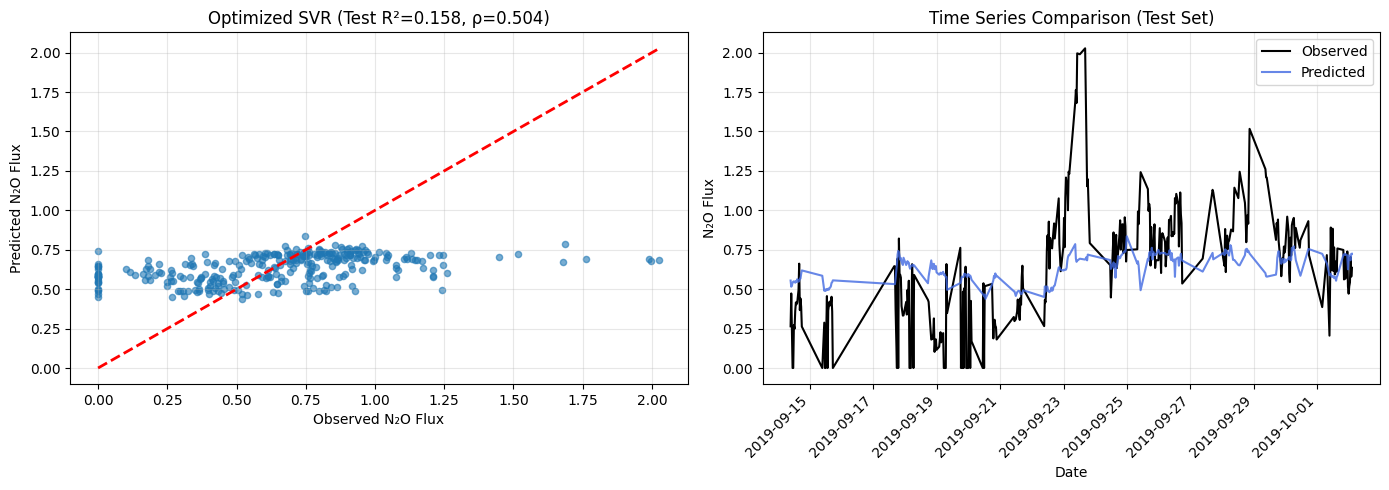


✓ Completed Hourly | Base
  Test R²: 0.1576
  Test ρ: 0.5036

OPTIMIZING: Hourly | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2018-07-19 06:45:00 → 2019-09-18 00:45:00 (2389 samples, 90.0%)
Test:      2019-09-18 01:15:00 → 2019-10-02 02:15:00 (266 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.3027
Completed 10/500 iterations. Best CV R²: -0.0587
Completed 15/500 iterations. Best CV R²: -0.0587
Completed 20/500 iterations. Best CV R²: -0.0587
Completed 25/500 iterations. Best CV R²: -0.0431
Completed 30/500 iterations. Best CV R²: -0.0413
Completed 35/500 iterations. Best CV R²: -0.0413
Completed 40/500 iterations. Best CV R²: -0.0413
Completed 45/500 iterations. Best CV R²: -0.0413
Completed 50/500 iterations. Best CV R²: -0.0413
Completed 55/500 iterations. Best CV R²: -0.0413
Completed 60/500 iterations. Best CV R²: -0.

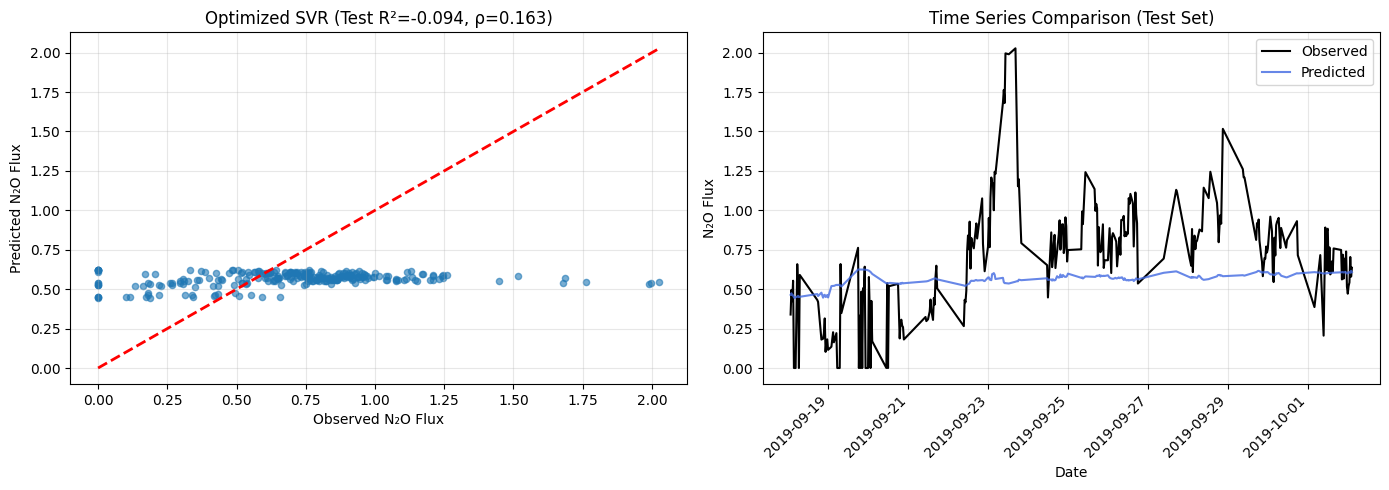


✓ Completed Hourly | Lag
  Test R²: -0.0936
  Test ρ: 0.1634

OPTIMIZING: Hourly | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2018-07-19 06:45:00 → 2019-09-18 00:45:00 (2389 samples, 90.0%)
Test:      2019-09-18 01:15:00 → 2019-10-02 02:15:00 (266 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.0674
Completed 10/500 iterations. Best CV R²: -0.0400
Completed 15/500 iterations. Best CV R²: -0.0400
Completed 20/500 iterations. Best CV R²: -0.0400
Completed 25/500 iterations. Best CV R²: -0.0336
Completed 30/500 iterations. Best CV R²: -0.0303
Completed 35/500 iterations. Best CV R²: -0.0303
Completed 40/500 iterations. Best CV R²: -0.0303
Completed 45/500 iterations. Best CV R²: -0.0303
Completed 50/500 iterations. Best CV R²: -0.0303
Completed 55/500 iterations. Best CV R²: -0.0303
Completed 60/500 iterations. Best CV R

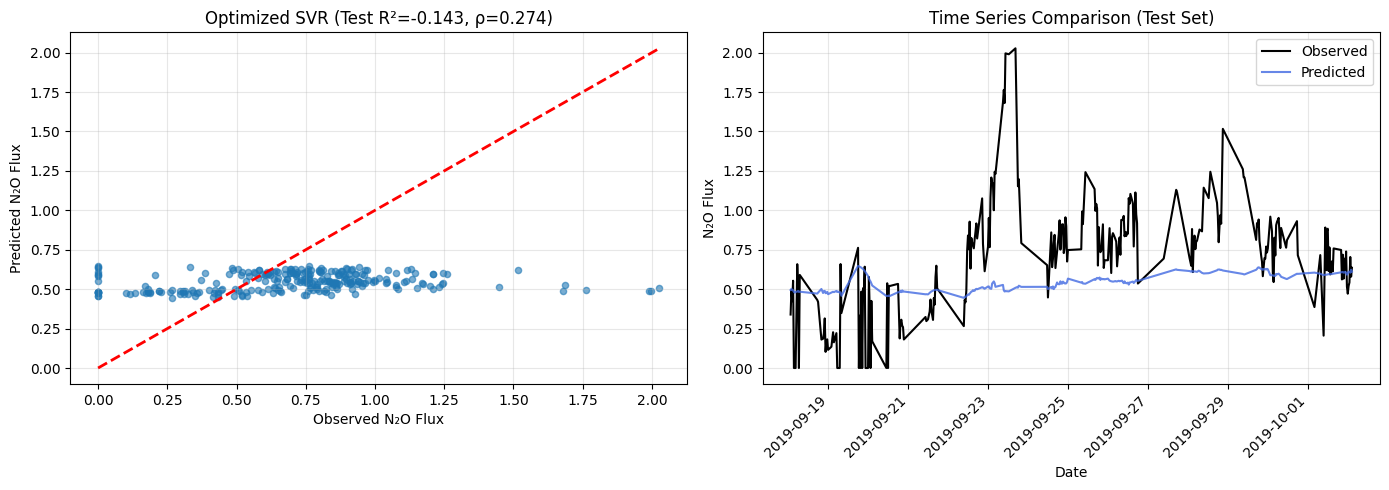


✓ Completed Hourly | Augmented
  Test R²: -0.1429
  Test ρ: 0.2740

OPTIMIZING: Daily | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2018-07-12 00:00:00 → 2019-09-15 00:00:00 (144 samples, 90.0%)
Test:      2019-09-17 00:00:00 → 2019-10-02 00:00:00 (16 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.0474
Completed 10/500 iterations. Best CV R²: -0.0474
Completed 15/500 iterations. Best CV R²: -0.0474
Completed 20/500 iterations. Best CV R²: -0.0474
Completed 25/500 iterations. Best CV R²: 0.0964
Completed 30/500 iterations. Best CV R²: 0.2211
Completed 35/500 iterations. Best CV R²: 0.2211
Completed 40/500 iterations. Best CV R²: 0.2211
Completed 45/500 iterations. Best CV R²: 0.2601
Completed 50/500 iterations. Best CV R²: 0.2601
Completed 55/500 iterations. Best CV R²: 0.2601
Completed 60/500 iterations. Best CV R²: 0.2601

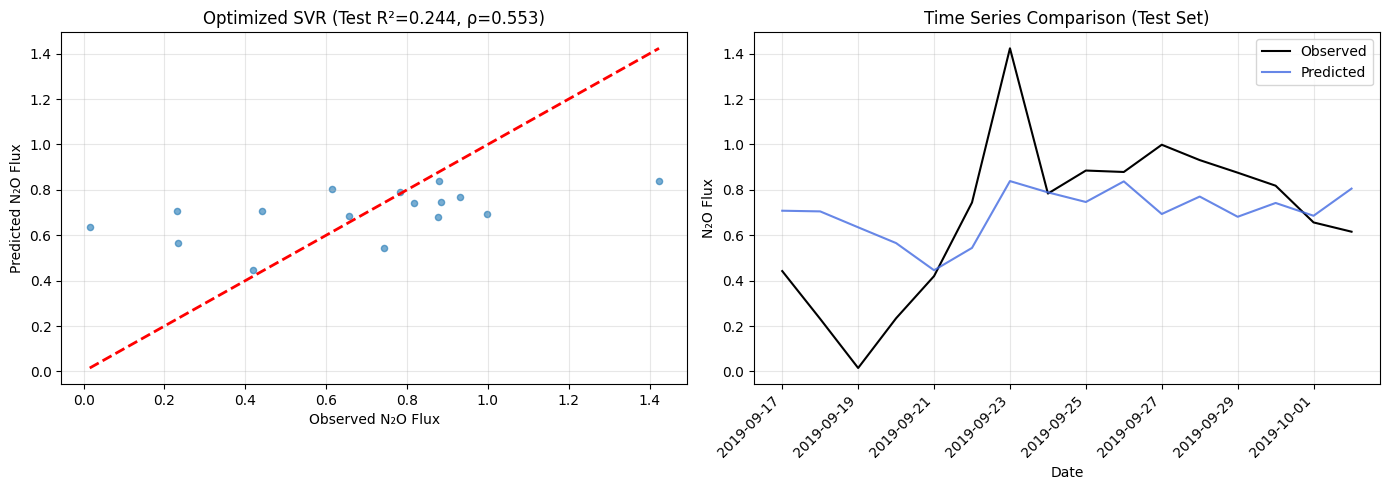


✓ Completed Daily | Base
  Test R²: 0.2442
  Test ρ: 0.5529

OPTIMIZING: Daily | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2018-07-19 00:00:00 → 2019-09-17 00:00:00 (131 samples, 89.7%)
Test:      2019-09-18 00:00:00 → 2019-10-02 00:00:00 (15 samples, 10.3%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.2971
Completed 10/500 iterations. Best CV R²: -0.1106
Completed 15/500 iterations. Best CV R²: -0.1106
Completed 20/500 iterations. Best CV R²: -0.1106
Completed 25/500 iterations. Best CV R²: -0.1061
Completed 30/500 iterations. Best CV R²: -0.1061
Completed 35/500 iterations. Best CV R²: -0.0817
Completed 40/500 iterations. Best CV R²: -0.0817
Completed 45/500 iterations. Best CV R²: -0.0817
Completed 50/500 iterations. Best CV R²: -0.0706
Completed 55/500 iterations. Best CV R²: -0.0706
Completed 60/500 iterations. Best CV R²: -0.0706

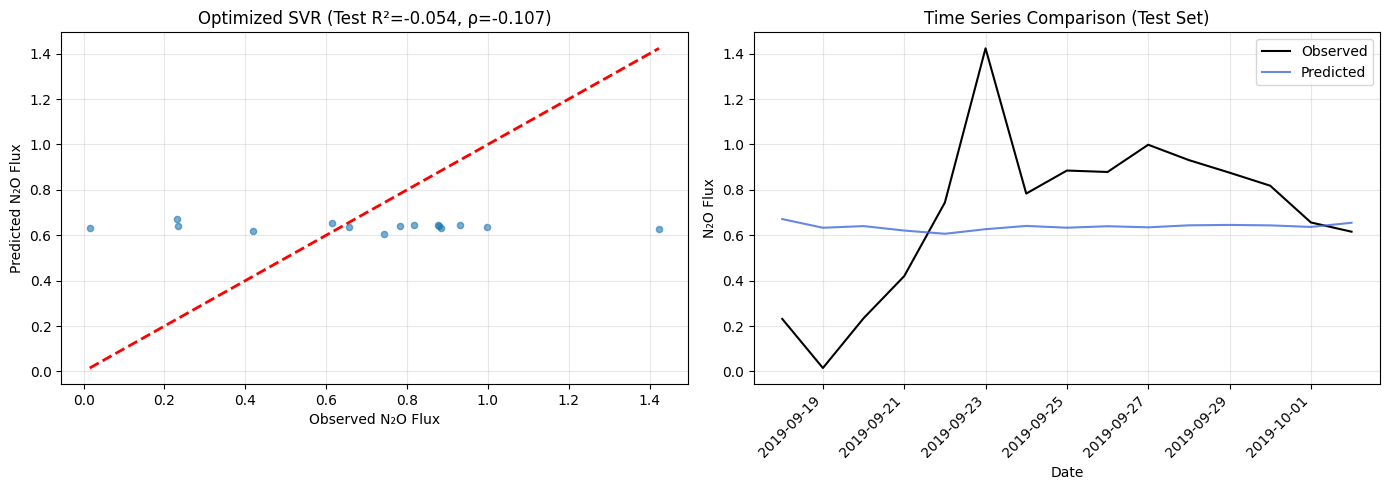


✓ Completed Daily | Lag
  Test R²: -0.0543
  Test ρ: -0.1071

OPTIMIZING: Daily | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2018-07-19 00:00:00 → 2019-09-17 00:00:00 (131 samples, 89.7%)
Test:      2019-09-18 00:00:00 → 2019-10-02 00:00:00 (15 samples, 10.3%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.1025
Completed 10/500 iterations. Best CV R²: -0.1015
Completed 15/500 iterations. Best CV R²: -0.0946
Completed 20/500 iterations. Best CV R²: -0.0946
Completed 25/500 iterations. Best CV R²: -0.0934
Completed 30/500 iterations. Best CV R²: -0.0934
Completed 35/500 iterations. Best CV R²: -0.0758
Completed 40/500 iterations. Best CV R²: -0.0758
Completed 45/500 iterations. Best CV R²: -0.0671
Completed 50/500 iterations. Best CV R²: -0.0370
Completed 55/500 iterations. Best CV R²: -0.0370
Completed 60/500 iterations. Best CV R²: 

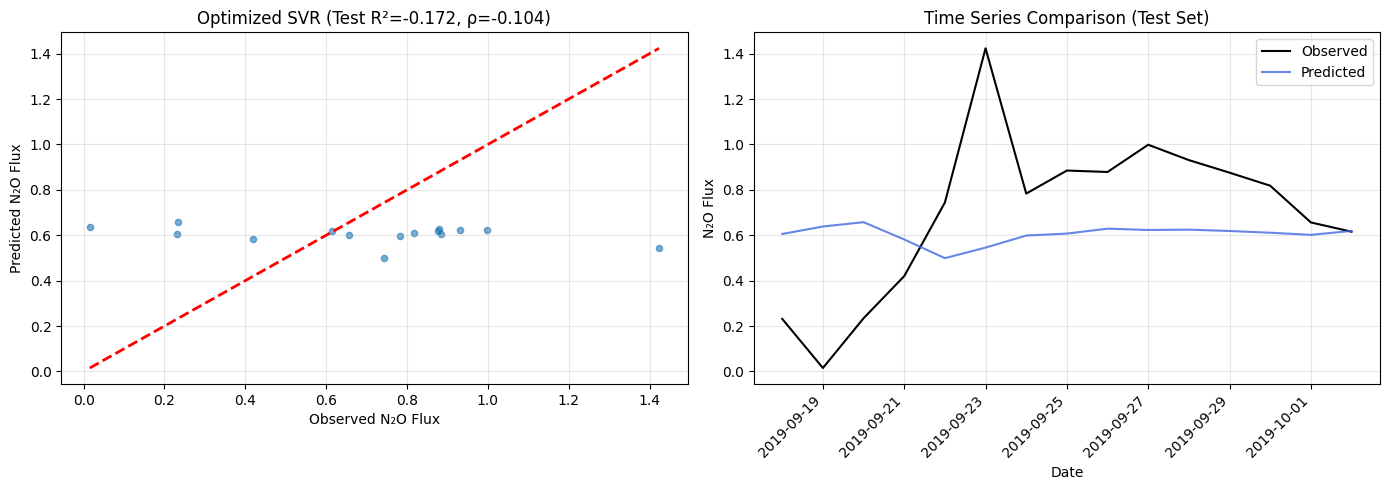


✓ Completed Daily | Augmented
  Test R²: -0.1722
  Test ρ: -0.1036


In [34]:
configurations = [
    ("Hourly", "Base", oensingen_1_lag, base_predictors),
    ("Hourly", "Lag", oensingen_1_lag, hourly_lag_predictors),
    ("Hourly", "Augmented", oensingen_1_lag, hourly_augmented_predictors),
    ("Daily", "Base", oensingen_1_daily, base_predictors),
    ("Daily", "Lag", oensingen_1_daily, daily_lag_predictors),
    ("Daily", "Augmented", oensingen_1_daily, daily_augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        best_params=best_params,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

In [35]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_svr_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2018-07-12 07:45:00 → 2019-09-09 01:45:00
Test  period: 2019-09-09 02:15:00 → 2019-10-04 23:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.313
  Spearman ρ:        0.653

Running original Hourly | Lag...
Train period: 2018-07-12 07:45:00 → 2019-08-18 11:15:00
Test  period: 2019-08-18 11:45:00 → 2019-10-04 23:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.131
  Spearman ρ:        0.505

Running original Hourly | Augmented...
Train period: 2018-07-12 07:45:00 → 2019-08-18 11:15:00
Test  period: 2019-08-18 11:45:00 → 2019-10-04 23:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.149
 

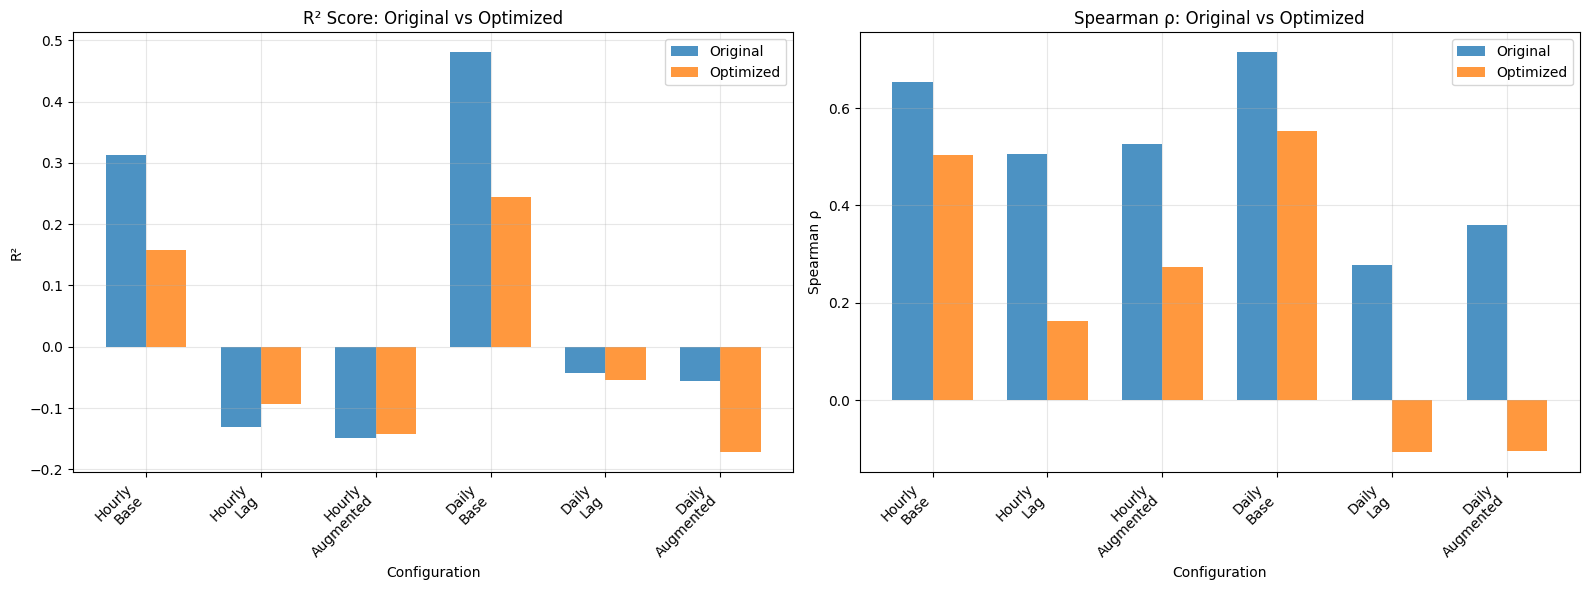

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Define dataset name
dataset_name = "Oensingen_2018-19"

# Create dataset subfolder inside existing svm_params folder
save_dir = os.path.join('svm_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to svm_params/Oensingen_2018-19!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 23
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/svm_params/Oensingen_2018-19

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ ORIGINAL   | ΔR²: -0.1551
Hourly          | Lag                  | ✓ OPTIMIZED  | ΔR²: +0.0375
Hourly          | Augmented            | ✓ OPTIMIZED  | ΔR²: +0.0057
Daily           | Base                 | ✓ ORIGINAL   | ΔR²: -0.2362
Daily           | Lag                  | ✓ ORIGINAL   | ΔR²: -0.0110
Daily           | Augmented            | ✓ ORIGINAL   | ΔR²: -0.1162


# Experiment 5: Aeschi

In [38]:
# FIX TIMESTAMP
aeschi_lag['Timestamp'] = pd.to_datetime(aeschi_lag['Timestamp'])
aeschi_lag = aeschi_lag.set_index('Timestamp').sort_index()

aeschi_daily['Date'] = pd.to_datetime(aeschi_daily['Date'])
aeschi_daily = aeschi_daily.set_index('Date').sort_index()

In [39]:
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing",
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "DaysSince_Mowing"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "DaysSince_Mowing"
]


OPTIMIZING: Hourly | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2019-05-19 19:45:00 → 2020-10-20 07:15:00 (5904 samples, 90.0%)
Test:      2020-10-20 07:45:00 → 2020-11-02 23:45:00 (657 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array i

Completed 5/500 iterations. Best CV R²: -0.6675


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array i

Completed 10/500 iterations. Best CV R²: -0.6675


...

Completed 490/500 iterations. Best CV R²: -0.0250


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array i

Completed 495/500 iterations. Best CV R²: -0.0250


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array i

Completed 500/500 iterations. Best CV R²: -0.0250

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  kernel: rbf
  C: 0.20803754152519396
  epsilon: 0.08096352749513717
  cache_size: 1000
  gamma: 0.0029168816267818036

Best CV R² (mean across 3 folds): -0.0250

Training final SVR model on 5904 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS BASELINE MODEL)
R² (linear scale): -0.9726
Spearman ρ:        -0.1421


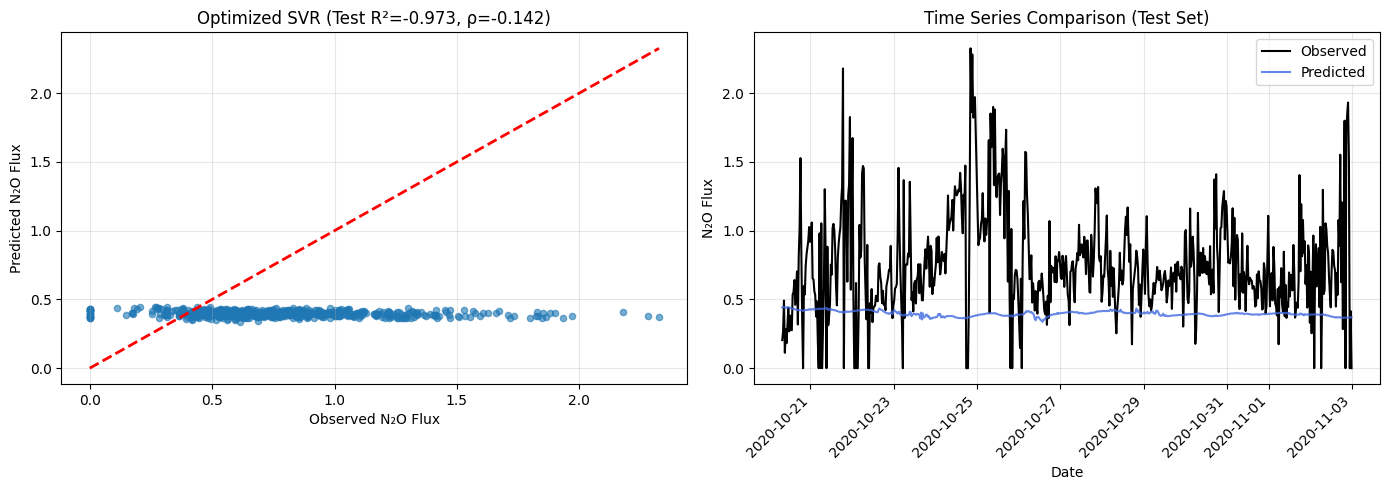


✓ Completed Hourly | Base
  Test R²: -0.9726
  Test ρ: -0.1421

OPTIMIZING: Hourly | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2019-05-24 01:45:00 → 2020-10-21 06:45:00 (5488 samples, 90.0%)
Test:      2020-10-21 07:15:00 → 2020-11-02 23:45:00 (610 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array i

Completed 5/500 iterations. Best CV R²: -1.2147


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array i

Completed 10/500 iterations. Best CV R²: -1.2147


...

Completed 490/500 iterations. Best CV R²: -0.2246


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array i

Completed 495/500 iterations. Best CV R²: -0.2246


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array i

Completed 500/500 iterations. Best CV R²: -0.2246

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  kernel: rbf
  C: 0.11740305412363267
  epsilon: 0.0352715161654633
  cache_size: 1000
  gamma: 0.0011137814705800316

Best CV R² (mean across 3 folds): -0.2246

Training final SVR model on 5488 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS BASELINE MODEL)
R² (linear scale): -1.1845
Spearman ρ:        0.1536


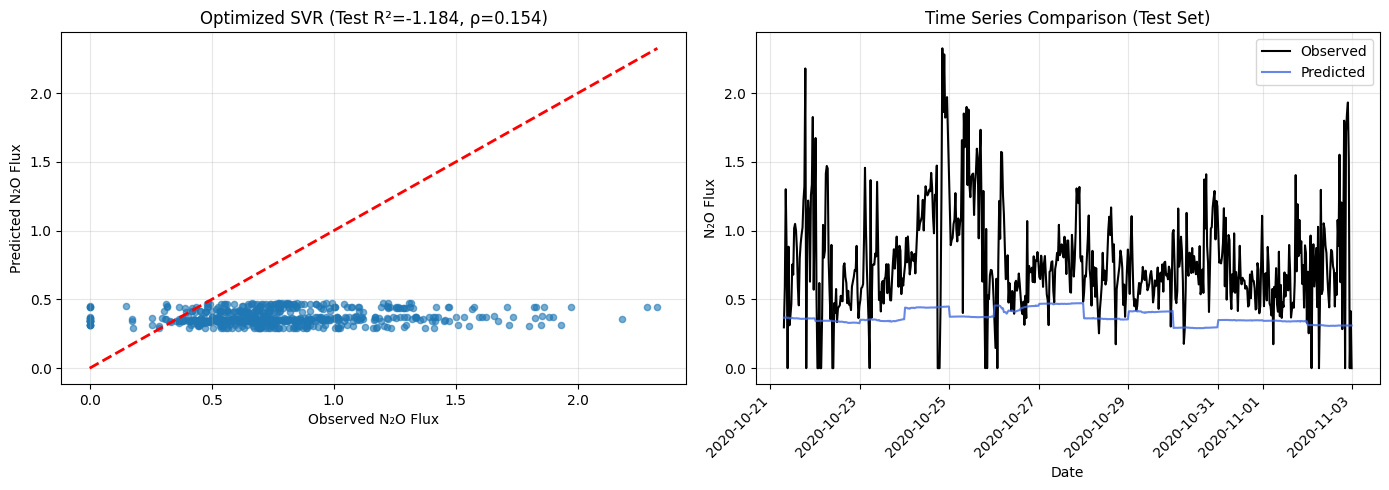


✓ Completed Hourly | Lag
  Test R²: -1.1845
  Test ρ: 0.1536

OPTIMIZING: Hourly | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2019-05-24 01:45:00 → 2020-10-21 06:45:00 (5488 samples, 90.0%)
Test:      2020-10-21 07:15:00 → 2020-11-02 23:45:00 (610 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array i

Completed 5/500 iterations. Best CV R²: -0.9747


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array i

Completed 10/500 iterations. Best CV R²: -0.9747


...

Completed 490/500 iterations. Best CV R²: -0.4017


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 495/500 iterations. Best CV R²: -0.4017


/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)
/var/folders/_3/dhm9h5w122sfbk56zms0llk00000gn/T/ipykernel_50197/297318464.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_val_lin, y_pred_lin)


Completed 500/500 iterations. Best CV R²: -0.4017

BAYESIAN OPTIMIZATION COMPLETE

Best parameters (selected via cross-validation):
  kernel: rbf
  C: 0.35291510672175475
  epsilon: 0.011786084704343537
  cache_size: 1000
  gamma: 0.0014279805977570736

Best CV R² (mean across 3 folds): -0.4017

Training final SVR model on 5488 samples (train+val combined)

FINAL MODEL PERFORMANCE (ON SAME TEST SET AS BASELINE MODEL)
R² (linear scale): -0.7628
Spearman ρ:        0.1510


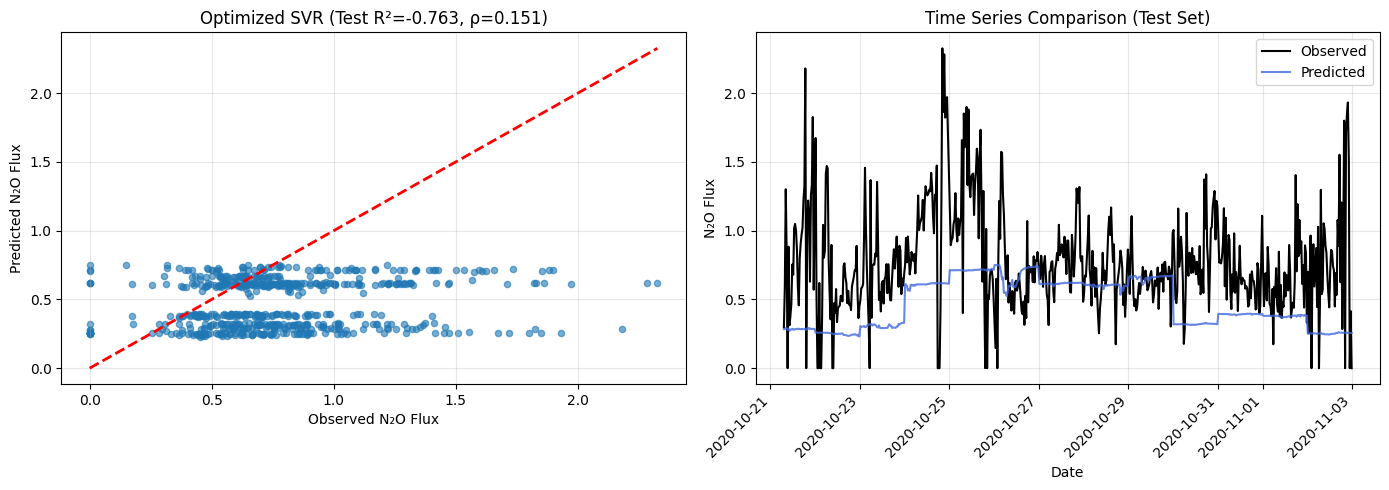


✓ Completed Hourly | Augmented
  Test R²: -0.7628
  Test ρ: 0.1510


In [42]:
configurations = [
    ("Hourly", "Base", aeschi_lag, base_predictors),
    ("Hourly", "Lag", aeschi_lag, lag_predictors),
    ("Hourly", "Augmented", aeschi_lag, augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        best_params=best_params,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

In [43]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_svr_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2019-05-10 00:15:00 → 2020-09-05 12:15:00
Test  period: 2020-09-05 13:45:00 → 2020-11-02 23:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -2.332
  Spearman ρ:        0.181

Running original Hourly | Lag...
Train period: 2019-05-10 00:15:00 → 2020-08-18 21:15:00
Test  period: 2020-08-18 21:45:00 → 2020-11-02 23:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -1.201
  Spearman ρ:        0.154

Running original Hourly | Augmented...
Train period: 2019-05-10 00:15:00 → 2020-08-18 21:15:00
Test  period: 2020-08-18 21:45:00 → 2020-11-02 23:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.627


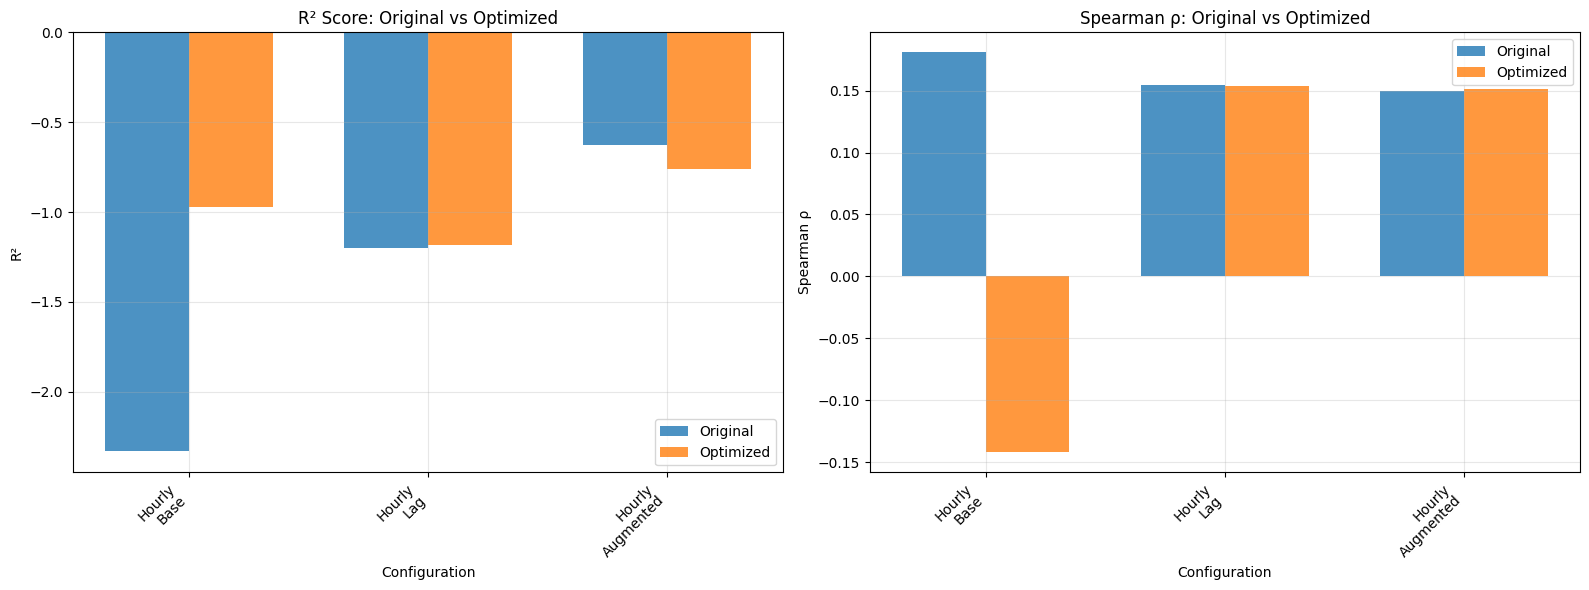

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# Define dataset name
dataset_name = "Aeschi"

# Create dataset subfolder inside existing svm_params folder
save_dir = os.path.join('svm_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (9 files: 3 original + 3 optimized + 3 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to svm_params/Aeschi!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (9 files: 3 original + 3 optimized + 3 best)

Total files saved: 14
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/svm_params/Aeschi

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ OPTIMIZED  | ΔR²: +1.3593
Hourly          | Lag                  | ✓ OPTIMIZED  | ΔR²: +0.0164
Hourly          | Augmented            | ✓ ORIGINAL   | ΔR²: -0.1361


# Experiment 6: Tanikon

In [46]:
# FIX TIMESTAMP
tanikon_lag['Timestamp'] = pd.to_datetime(tanikon_lag['Timestamp'])
tanikon_lag = tanikon_lag.set_index('Timestamp').sort_index()

tanikon_daily['Date'] = pd.to_datetime(tanikon_daily['Date'])
tanikon_daily = tanikon_daily.set_index('Date').sort_index()

In [47]:
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]


OPTIMIZING: Hourly | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2023-12-04 16:15:00 → 2025-04-13 09:15:00 (18632 samples, 90.0%)
Test:      2025-04-13 09:45:00 → 2025-06-03 21:45:00 (2071 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: 0.0204
Completed 10/500 iterations. Best CV R²: 0.0204
Completed 15/500 iterations. Best CV R²: 0.0204
Completed 20/500 iterations. Best CV R²: 0.0204
Completed 25/500 iterations. Best CV R²: 0.0204
Completed 30/500 iterations. Best CV R²: 0.0204
Completed 35/500 iterations. Best CV R²: 0.0204
Completed 40/500 iterations. Best CV R²: 0.0204
Completed 45/500 iterations. Best CV R²: 0.0204
Completed 50/500 iterations. Best CV R²: 0.0204
Completed 55/500 iterations. Best CV R²: 0.0204
Completed 60/500 iterations. Best CV R²: 0.0204
Completed 65/500 iterations. Best CV R²: 0.0204
Completed 70/500 i

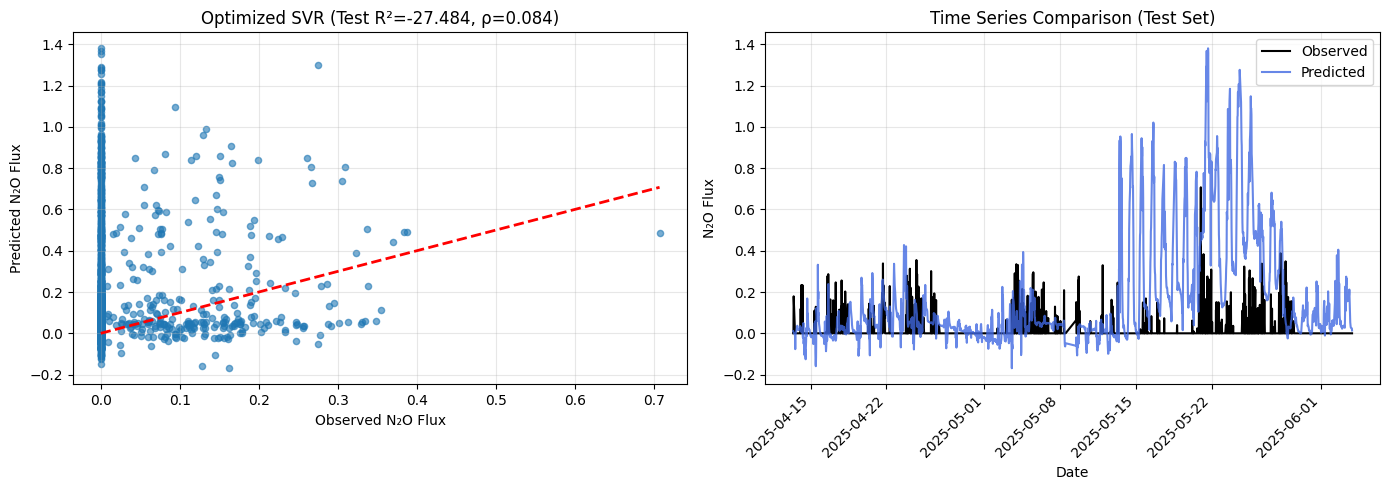


✓ Completed Hourly | Base
  Test R²: -27.4839
  Test ρ: 0.0836

OPTIMIZING: Hourly | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2023-12-11 00:15:00 → 2025-04-15 10:45:00 (17897 samples, 90.0%)
Test:      2025-04-15 11:15:00 → 2025-06-03 21:45:00 (1989 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.0645
Completed 10/500 iterations. Best CV R²: -0.0645
Completed 15/500 iterations. Best CV R²: -0.0591
Completed 20/500 iterations. Best CV R²: -0.0591
Completed 25/500 iterations. Best CV R²: -0.0537
Completed 30/500 iterations. Best CV R²: -0.0537
Completed 35/500 iterations. Best CV R²: -0.0537
Completed 40/500 iterations. Best CV R²: -0.0537
Completed 45/500 iterations. Best CV R²: -0.0490
Completed 50/500 iterations. Best CV R²: -0.0490
Completed 55/500 iterations. Best CV R²: -0.0471
Completed 60/500 iterations. Best CV R²:

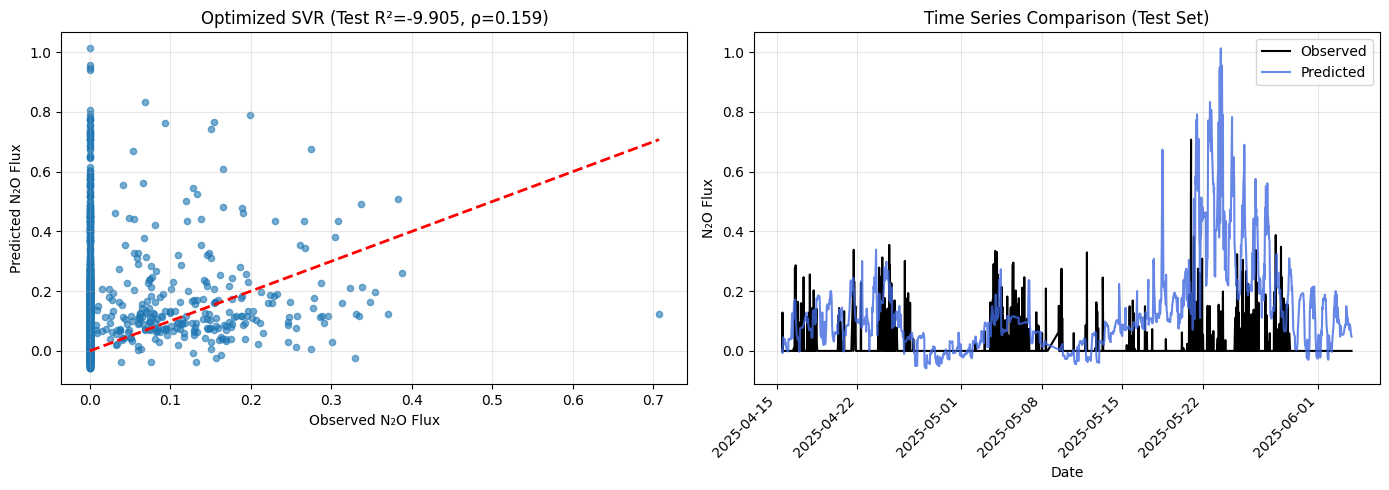


✓ Completed Hourly | Lag
  Test R²: -9.9045
  Test ρ: 0.1592

OPTIMIZING: Hourly | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2023-12-11 00:15:00 → 2025-04-15 10:45:00 (17897 samples, 90.0%)
Test:      2025-04-15 11:15:00 → 2025-06-03 21:45:00 (1989 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.0630
Completed 10/500 iterations. Best CV R²: -0.0630
Completed 15/500 iterations. Best CV R²: -0.0630
Completed 20/500 iterations. Best CV R²: -0.0630
Completed 25/500 iterations. Best CV R²: -0.0630
Completed 30/500 iterations. Best CV R²: -0.0611
Completed 35/500 iterations. Best CV R²: -0.0348
Completed 40/500 iterations. Best CV R²: -0.0348
Completed 45/500 iterations. Best CV R²: -0.0348
Completed 50/500 iterations. Best CV R²: -0.0348
Completed 55/500 iterations. Best CV R²: -0.0348
Completed 60/500 iterations. Best CV

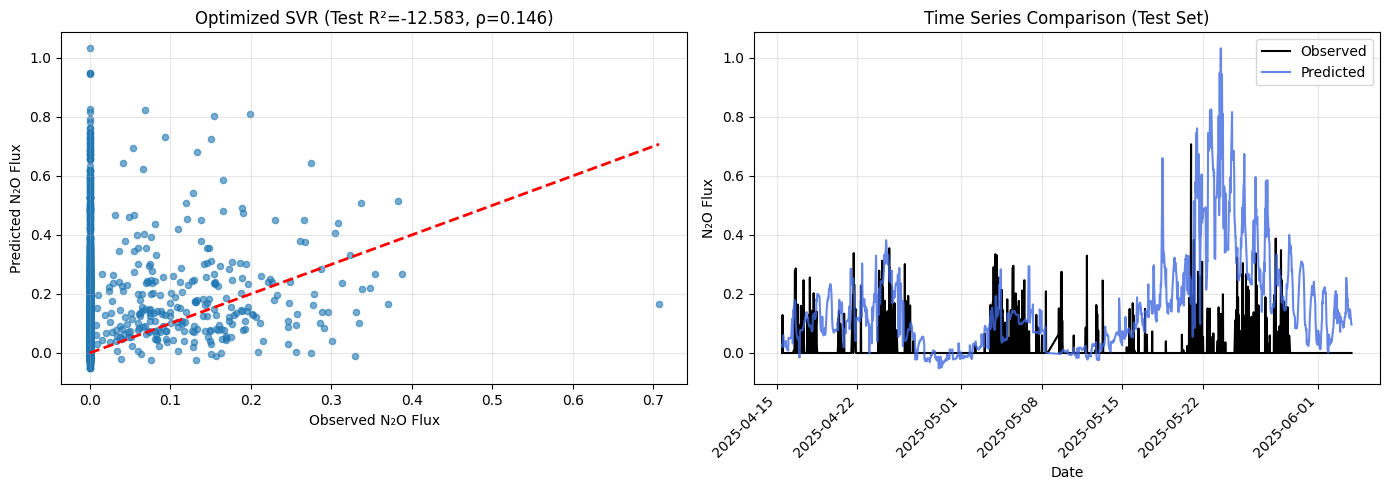


✓ Completed Hourly | Augmented
  Test R²: -12.5835
  Test ρ: 0.1456

OPTIMIZING: Daily | Base
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2023-12-05 00:00:00 → 2025-04-10 00:00:00 (718 samples, 90.0%)
Test:      2025-04-11 00:00:00 → 2025-05-29 00:00:00 (80 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.6069
Completed 10/500 iterations. Best CV R²: -0.6069
Completed 15/500 iterations. Best CV R²: -0.3055
Completed 20/500 iterations. Best CV R²: -0.3055
Completed 25/500 iterations. Best CV R²: -0.1396
Completed 30/500 iterations. Best CV R²: -0.0082
Completed 35/500 iterations. Best CV R²: -0.0082
Completed 40/500 iterations. Best CV R²: -0.0082
Completed 45/500 iterations. Best CV R²: -0.0082
Completed 50/500 iterations. Best CV R²: -0.0082
Completed 55/500 iterations. Best CV R²: -0.0082
Completed 60/500 iterations. Best CV R²

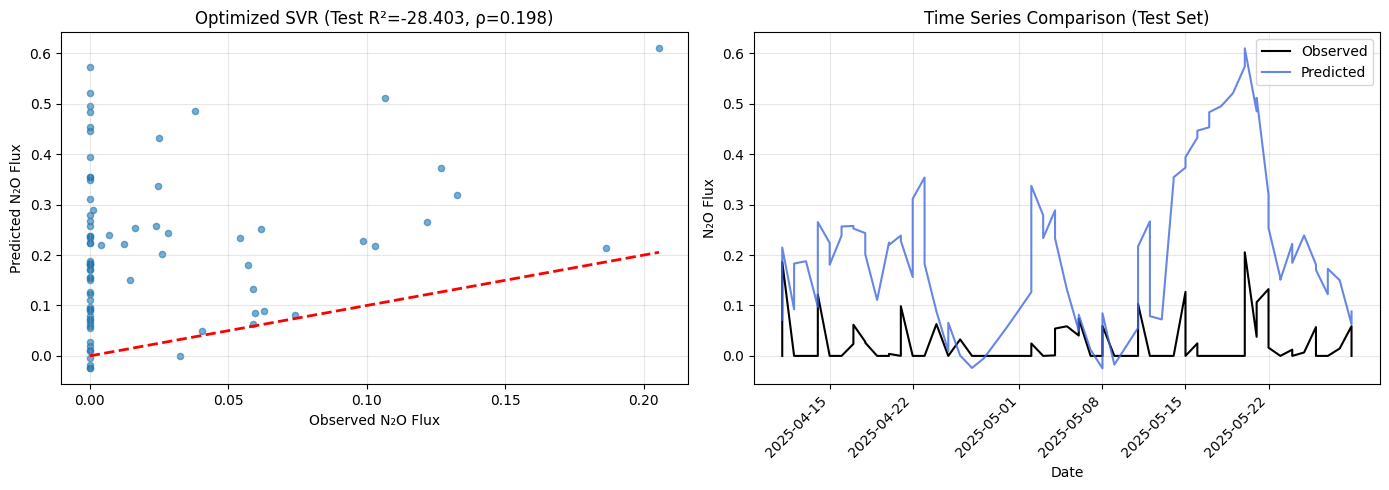


✓ Completed Daily | Base
  Test R²: -28.4031
  Test ρ: 0.1977

OPTIMIZING: Daily | Lag
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2023-12-11 00:00:00 → 2025-04-12 00:00:00 (692 samples, 90.0%)
Test:      2025-04-12 00:00:00 → 2025-05-29 00:00:00 (77 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.8953
Completed 10/500 iterations. Best CV R²: -0.8953
Completed 15/500 iterations. Best CV R²: -0.7919
Completed 20/500 iterations. Best CV R²: -0.7919
Completed 25/500 iterations. Best CV R²: -0.4553
Completed 30/500 iterations. Best CV R²: -0.4553
Completed 35/500 iterations. Best CV R²: -0.4553
Completed 40/500 iterations. Best CV R²: -0.4553
Completed 45/500 iterations. Best CV R²: -0.4553
Completed 50/500 iterations. Best CV R²: -0.4553
Completed 55/500 iterations. Best CV R²: -0.4553
Completed 60/500 iterations. Best CV R²: -0.34

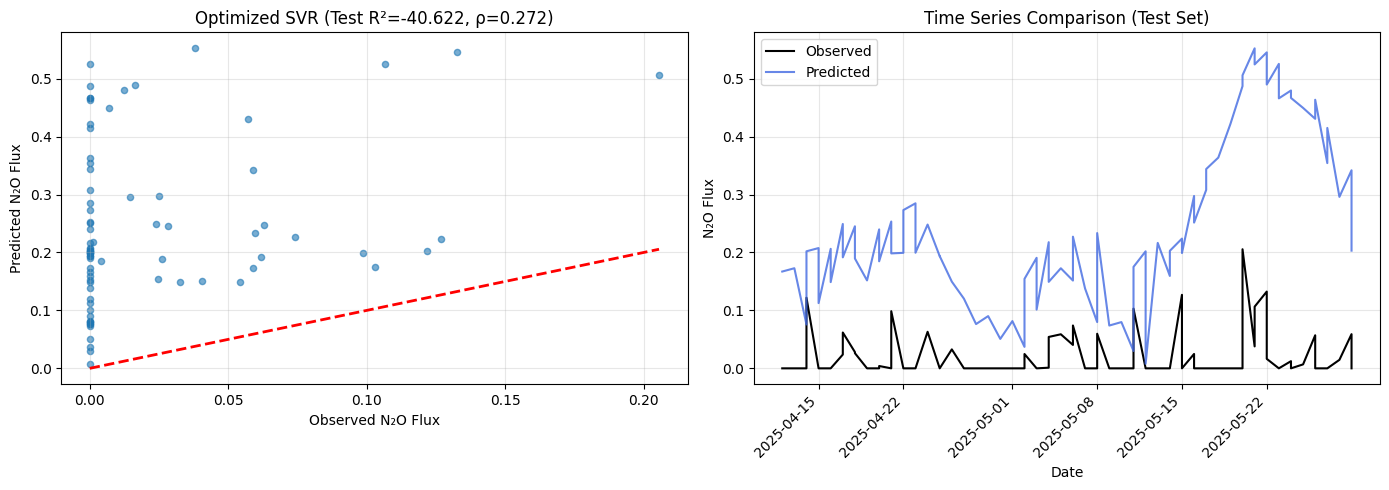


✓ Completed Daily | Lag
  Test R²: -40.6223
  Test ρ: 0.2717

OPTIMIZING: Daily | Augmented
Starting SVR hyperparameter search with cross-validation...
Search type: Bayesian Optimization (TPE)
Iterations: 500
CV folds: 3

Train+Val: 2023-12-11 00:00:00 → 2025-04-12 00:00:00 (692 samples, 90.0%)
Test:      2025-04-12 00:00:00 → 2025-05-29 00:00:00 (77 samples, 10.0%)

⚠️  Using 3-fold time series CV on Train+Val data
Completed 5/500 iterations. Best CV R²: -0.5480
Completed 10/500 iterations. Best CV R²: -0.5480
Completed 15/500 iterations. Best CV R²: -0.4599
Completed 20/500 iterations. Best CV R²: -0.4599
Completed 25/500 iterations. Best CV R²: -0.4599
Completed 30/500 iterations. Best CV R²: -0.2187
Completed 35/500 iterations. Best CV R²: -0.1131
Completed 40/500 iterations. Best CV R²: -0.1131
Completed 45/500 iterations. Best CV R²: -0.1131
Completed 50/500 iterations. Best CV R²: -0.1131
Completed 55/500 iterations. Best CV R²: -0.1131
Completed 60/500 iterations. Best CV R²: 

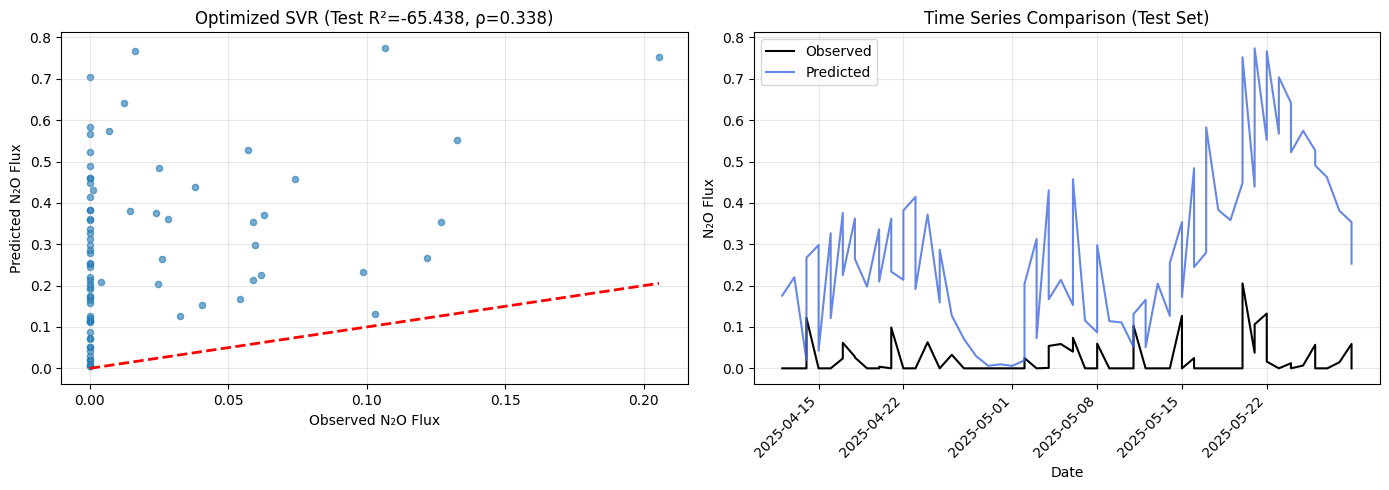


✓ Completed Daily | Augmented
  Test R²: -65.4377
  Test ρ: 0.3383


In [50]:
configurations = [
    ("Hourly", "Base", tanikon_lag, base_predictors),
    ("Hourly", "Lag", tanikon_lag, hourly_lag_predictors),
    ("Hourly", "Augmented", tanikon_lag, hourly_augmented_predictors),
    ("Daily", "Base", tanikon_daily, base_predictors),
    ("Daily", "Lag", tanikon_daily, daily_lag_predictors),
    ("Daily", "Augmented", tanikon_daily, daily_augmented_predictors),
]

all_optimized_results = []
all_best_params = {}

for temporal, pred_type, df, predictors in configurations:
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # CORRECTED: Only 7 return values now
    best_params, search_results, X_trainval, y_trainval, X_test, y_test, offset = hyperparameter_search_timeseries(
        df=df, 
        predictors=predictors, 
        target="N2O_Flux_ln", 
        test_size=0.1
    )
    
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # CORRECTED: train_final_model also needs updating
    final_results = train_final_model(
        X_trainval=X_trainval,  # Changed from X_train
        y_trainval=y_trainval,  # Changed from y_train
        X_test=X_test,
        y_test=y_test,
        offset=offset,
        best_params=best_params,
        plot=True
    )
    
    all_optimized_results.append({
        'Temporal': temporal, 
        'Predictors': pred_type, 
        'R2_optimized': final_results['r2'], 
        'Spearman_optimized': final_results['spearman_rho'], 
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Test R²: {final_results['r2']:.4f}")
    print(f"  Test ρ: {final_results['spearman_rho']:.4f}")

In [51]:
# Re-run original models for comparison
original_results = []
all_original_params = {}  # ADD THIS: Store original parameters

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_svr_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        plot=False
    )
    
    # Store original parameters
    config_name = f"{temporal}_{pred_type}"
    all_original_params[config_name] = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,  # ← FIXED
        'subsample': 0.8,      # ← FIXED
        'colsample_bytree': 0.8,  # ← FIXED
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': 42
    }
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

# ADD THIS: Flag which model is better
comparison_df['Better_Model'] = comparison_df.apply(
    lambda row: 'Optimized' if row['R2_optimized'] > row['R2_original'] else 'Original', 
    axis=1
)

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement', 'Better_Model']].to_string(index=False))


Running original Hourly | Base...
Train period: 2023-11-07 15:45:00 → 2025-02-17 03:45:00
Test  period: 2025-02-17 04:15:00 → 2025-06-05 00:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -32.892
  Spearman ρ:        0.088

Running original Hourly | Lag...
Train period: 2023-11-07 15:45:00 → 2025-01-30 12:15:00
Test  period: 2025-01-30 12:45:00 → 2025-06-05 00:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -20.637
  Spearman ρ:        0.148

Running original Hourly | Augmented...
Train period: 2023-11-07 15:45:00 → 2025-01-30 12:15:00
Test  period: 2025-01-30 12:45:00 → 2025-06-05 00:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -23.6

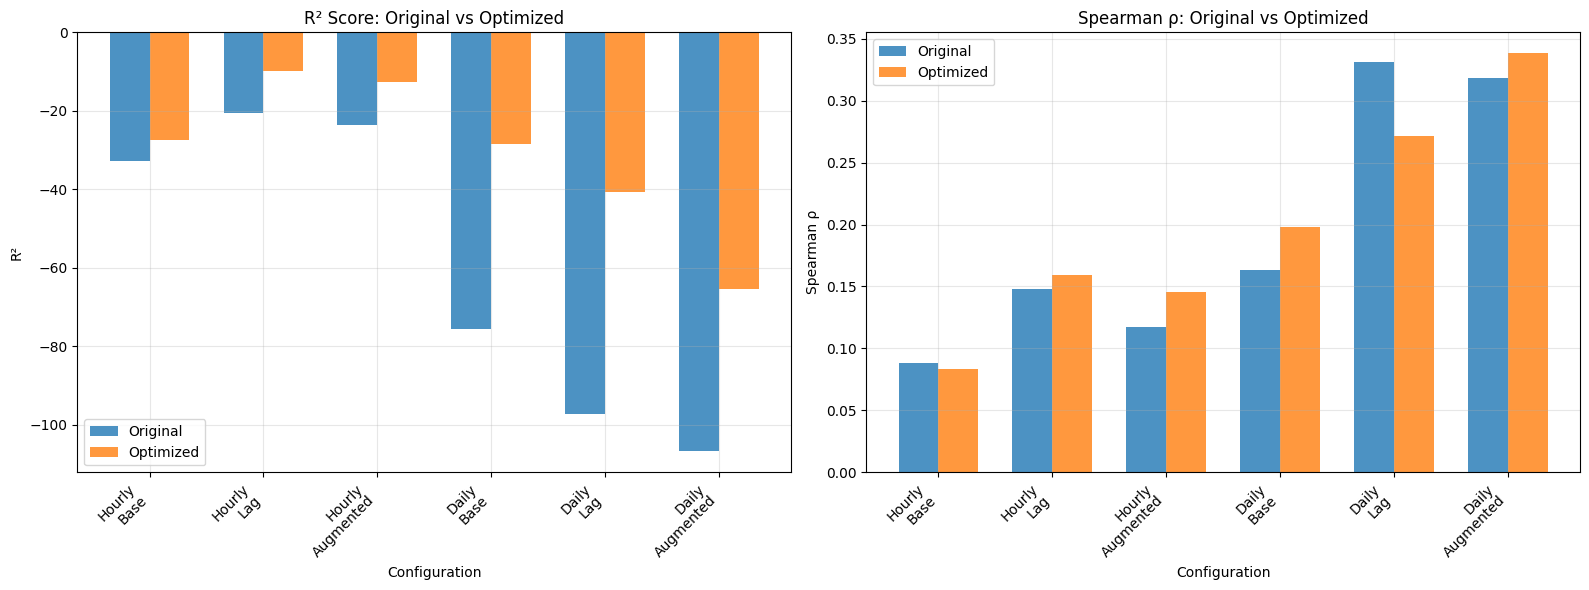

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# Define dataset name
dataset_name = "Tanikon"

# Create dataset subfolder inside existing svm_params folder
save_dir = os.path.join('svm_params', dataset_name)
os.makedirs(save_dir, exist_ok=True)

# Save comparison dataframe
comparison_df.to_csv(os.path.join(save_dir, 'optimization_comparison.csv'), index=False)

# Save both original and optimized parameters as JSON
with open(os.path.join(save_dir, 'original_hyperparameters.json'), 'w') as f:
    json.dump(all_original_params, f, indent=4)

with open(os.path.join(save_dir, 'optimized_hyperparameters.json'), 'w') as f:
    json.dump(all_best_params, f, indent=4)

# ADD THIS: Save best performing parameters (choose better of original vs optimized)
all_best_performing_params = {}
for _, row in comparison_df.iterrows():
    config_name = f"{row['Temporal']}_{row['Predictors']}"
    if row['Better_Model'] == 'Optimized':
        all_best_performing_params[config_name] = all_best_params[config_name]
    else:
        all_best_performing_params[config_name] = all_original_params[config_name]

with open(os.path.join(save_dir, 'best_performing_hyperparameters.json'), 'w') as f:
    json.dump(all_best_performing_params, f, indent=4)

# Save each configuration's params as separate JSON files
for config_name in all_best_params.keys():
    # Original params
    with open(os.path.join(save_dir, f'{config_name}_original_params.json'), 'w') as f:
        json.dump(all_original_params[config_name], f, indent=4)
    
    # Optimized params
    with open(os.path.join(save_dir, f'{config_name}_optimized_params.json'), 'w') as f:
        json.dump(all_best_params[config_name], f, indent=4)
    
    # Best performing params
    with open(os.path.join(save_dir, f'{config_name}_best_params.json'), 'w') as f:
        json.dump(all_best_performing_params[config_name], f, indent=4)

# Save detailed comparison with both parameter sets
comparison_with_params = comparison_df.copy()
comparison_with_params['Original_Params'] = comparison_with_params.apply(
    lambda row: all_original_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Optimized_Params'] = comparison_with_params.apply(
    lambda row: all_best_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params['Best_Performing_Params'] = comparison_with_params.apply(
    lambda row: all_best_performing_params[f"{row['Temporal']}_{row['Predictors']}"], axis=1
)
comparison_with_params.to_csv(os.path.join(save_dir, 'detailed_comparison_with_params.csv'), index=False)

print(f"\nResults saved to {save_dir}!")
print("  - optimization_comparison.csv")
print("  - original_hyperparameters.json")
print("  - optimized_hyperparameters.json")
print("  - best_performing_hyperparameters.json (automatically selects better model)")
print("  - detailed_comparison_with_params.csv")
print("  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)")
print(f"\nTotal files saved: {len(os.listdir(save_dir))}")
print(f"Full path: {os.path.abspath(save_dir)}")

# Print summary of which models performed better
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
for _, row in comparison_df.iterrows():
    winner = "✓ OPTIMIZED" if row['Better_Model'] == 'Optimized' else "✓ ORIGINAL"
    print(f"{row['Temporal']:15} | {row['Predictors']:20} | {winner:12} | ΔR²: {row['R2_improvement']:+.4f}")


Results saved to svm_params/Tanikon!
  - optimization_comparison.csv
  - original_hyperparameters.json
  - optimized_hyperparameters.json
  - best_performing_hyperparameters.json (automatically selects better model)
  - detailed_comparison_with_params.csv
  - Individual config param files (18 files: 6 original + 6 optimized + 6 best)

Total files saved: 23
Full path: /Users/cristihiropedi/Documents/ETH/Year2/Sem1/DS_Lab/N2O_Emissions_Prediction/further_experiments/svm_params/Tanikon

MODEL PERFORMANCE SUMMARY
Hourly          | Base                 | ✓ OPTIMIZED  | ΔR²: +5.4083
Hourly          | Lag                  | ✓ OPTIMIZED  | ΔR²: +10.7328
Hourly          | Augmented            | ✓ OPTIMIZED  | ΔR²: +11.0447
Daily           | Base                 | ✓ OPTIMIZED  | ΔR²: +47.1799
Daily           | Lag                  | ✓ OPTIMIZED  | ΔR²: +56.5930
Daily           | Augmented            | ✓ OPTIMIZED  | ΔR²: +41.3053
